# CLIP Spatial Reasoning Explainability

**Author:** Md Mahibul Haque  
**Dataset:** Visual Spatial Reasoning (VSR) — all 3,386 selected examples across 10 relation types [2]  
**Main model:** OpenAI CLIP ViT-B/32 [1]  
**Supporting tools:** OWL-ViT for object detection [8] · Grad-CAM for visual attribution [9, 14] · BLIP for model comparison [13]

---

## What this project is about

Vision-language models like CLIP are now used widely in image retrieval, visual question answering, and multimodal search. Most of this success rests on learning what objects *are* — but much less on learning where objects *are* in relation to each other. Two sentences like *"the cat is in front of the dog"* and *"the cat is behind the dog"* describe entirely different spatial configurations while containing the same words and objects. A model with genuine spatial understanding should treat these sentences very differently. A model that only learned object co-occurrence statistics will struggle.

This notebook investigates that gap systematically. Using the Visual Spatial Reasoning (VSR) dataset [2] and CLIP ViT-B/32 [1] as the primary subject, it runs a chain of seven experiments designed to answer not just *whether* CLIP fails at spatial reasoning, but *how* and *why* it fails — and whether a differently-trained model (BLIP [13]) shows the same failure modes. Three guiding questions structure the investigation:

1. When CLIP appears to get a spatial relation right, is it reasoning about 3D space or exploiting a simpler 2D visual shortcut?
2. At what level of the model does spatial information break down — visual encoder, text encoder, or cross-modal matching?
3. Does the choice of visual backbone and training objective change how much a model exploits positional shortcuts?

---

---

## Research map

The table below lists every experiment and sub-experiment, the question it addresses, its key output, and its role in the overall argument. Reading this table first gives a full picture of the research design before any code is run.

| Experiment | Sub-experiment | Research question | Key output | Role in the argument |
|---|---|---|---|---|
| **1. Baseline accuracy** | — | Can CLIP classify VSR image-caption pairs as TRUE/FALSE at better than chance? | 54.43% accuracy · ROC-AUC 0.5656 · per-relation breakdown · similarity distributions | Establishes the starting point. Near-chance performance motivates every later experiment. |
| **2. Spatial shortcut analysis** | **2.1 Vertical-position heuristic** | Does CLIP benefit from the natural-photography regularity that closer objects appear lower in the frame? | 63.21% accuracy when heuristic matches vs 40.06% when it contradicts · χ²=49.9 · p≈0 | Core evidence for the "right for the wrong reasons" hypothesis — the most important finding. |
| | **2.2 Occlusion analysis** | Does CLIP perform better when object bounding boxes overlap, suggesting visual occlusion? | Accuracy gap (occluded vs separated) · Mann-Whitney p-value on IoU distributions | Tests a second independent depth cue beyond vertical position. |
| **3. Foil test** | — | When shown both the correct caption and its direction-swapped opposite, does CLIP reliably prefer the correct one? | 52.33% preference rate · mean score gap 0.0006 | More natural CLIP-style ranking evaluation; extends Exp 1 finding to the comparative setting. |
| **4. Text embedding geometry** | **4.1 Final-layer similarity** | Are opposite spatial captions distinguishable as vectors in CLIP's text embedding space? | Cosine similarity ≈ 0.98 for all tested pairs | Identifies the root cause: the text encoder cannot distinguish opposite spatial directions. |
| | **4.2 Layer-wise evolution** | At which transformer layer do opposite spatial captions become indistinguishable? | Similarity curves across all 12 text encoder layers | Pinpoints where the failure begins (Layer 1 — vocabulary level). |
| **5. Visual attribution (Grad-CAM)** | **5.1 Aggregate maps** | Does CLIP's visual attention differ systematically across relation types? | Average heatmap per relation · vertical-bias statistics table | Shows whether attention aligns spatially with what each relation requires. |
| | **5.2 Attention entropy** | Is attention more scattered for wrong predictions or for harder relations? | Entropy per example · Mann-Whitney test (2D vs 3D) | Tests whether spatial confusion is reflected in visual attention spread. |
| | **5.3 Per-sample visualisation** | What do individual Grad-CAM maps reveal qualitatively? | 16-image qualitative grid (8 correct, 8 incorrect) | Makes aggregate findings concrete with directly inspectable examples. |
| | **5.4 Quantified object attention** | What fraction of attention falls on the subject, object, space between, and background? | Mean attention fractions for four regions · comparison by correctness and relation group | Directly quantifies the supervisor's H1–H4 hypotheses about where the model looks. |
| **6. Cross-modal foil geometry** | — | Is the image embedding geometrically closer to the correct caption than to the foil? | sim(image, correct) vs sim(image, foil) · mean gap · Wilcoxon p-value | Connects the text-geometry finding (Exp 4) to actual image-caption matching scores. |
| **7. BLIP comparison** | — | Does a model with denser cross-modal supervision show less shortcut reliance? | BLIP accuracy 61.61% vs CLIP 54.43% · BLIP foil rate 65.73% vs CLIP 52.33% · BLIP heuristic gap −6.33% vs CLIP +23.15% | Tests the supervisor's backbone-choice hypothesis with a concrete comparative baseline. |

---

In [1]:
!pip install -q transformers datasets grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch
import torch.nn.functional as F
from transformers import (
    CLIPModel, CLIPProcessor, CLIPTokenizer,
    OwlViTProcessor, OwlViTForObjectDetection,
)
from datasets import load_dataset
import requests
from PIL import Image
import io, os, copy, hashlib, pickle, warnings
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from scipy.stats import entropy as scipy_entropy
from tqdm.auto import tqdm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings('ignore')

# ── Device: CUDA (RTX 3080 Ti) > CPU ─────────────────────────────────────────
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
    torch.set_num_threads(8)  # Optimize for Ryzen 9 5950X (16 cores)

print(f"Device  : {device}")
if device == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"PyTorch : {torch.__version__}")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Outputs : {OUTPUT_DIR.resolve()}")

Device  : cuda
GPU     : Tesla T4
VRAM    : 14.6 GB
PyTorch : 2.11.0+cu128
Outputs : /content/outputs


---

## Step 1 — Environment and model setup

The cell above loaded every Python library this notebook depends on, selected the compute device, and confirmed GPU availability.

This hardware matters practically. Running Grad-CAM gradient computations for all 3,386 images, CLIP inference on the same set, and BLIP inference on top together involve tens of millions of neural network operations. The GPU handles these in parallel, reducing total computation from many hours to a manageable session. All figures and result files are written to the `outputs` folder shown in the last line. Cells can be re-run individually without re-running the full notebook, as all expensive results are cached to disk.

---
## Step 1 — Load CLIP and define helper functions

In [3]:
MODEL_NAME = "openai/clip-vit-base-patch32"
print(f"Loading CLIP: {MODEL_NAME}")

clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_model     = CLIPModel.from_pretrained(MODEL_NAME).to(device)
clip_tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME)
clip_model.eval()

print(f"  Loaded on {device} | proj_dim={clip_model.config.projection_dim}")

Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

  Loaded on cuda | proj_dim=512


### What CLIP is and how it works

CLIP (**Contrastive Language-Image Pretraining**) is a vision-language model introduced by Radford et al. at OpenAI [1]. It was trained on approximately 400 million image-text pairs from the internet using a contrastive objective: matching image-text pairs are pushed together in a shared representation space, while non-matching pairs are pushed apart. No explicit supervision about object categories, spatial layout, or linguistic structure was provided — the model learned purely from statistical co-occurrence at scale.

The version used here is **ViT-B/32**: a Vision Transformer (ViT [6]) at base size, processing images as non-overlapping 32×32 pixel patches. A 224×224 input image produces a 7×7 grid of 49 patch tokens. These pass through 12 transformer blocks, and the final CLS token is projected into a **512-dimensional image embedding**. On the text side, the caption is tokenised and processed by a separate 12-layer transformer, producing a **512-dimensional text embedding** from the end-of-sequence token.

Similarity between image and caption is measured by the **cosine similarity** of these two unit-normalised 512-dimensional vectors — a single number between −1 and 1. For real image-caption pairs from everyday photographs, CLIP scores typically fall between 0.15 and 0.37. The `proj_dim=512` in the output above confirms this shared dimensionality for the loaded model.

The critical limitation this project investigates: CLIP's training never required the model to distinguish *how* objects are spatially arranged relative to each other — only *whether* a whole image roughly matches a whole caption. This design choice is precisely what makes spatial reasoning a meaningful test of its abilities.

### Helper functions defined

Three utility functions are created here and called throughout every subsequent experiment.

**`load_image_cached`** downloads images from the web URLs stored in the VSR dataset and saves them to a local directory. On the first run this populated a cache of 6,259 unique COCO images. On every subsequent run, images are read from disk in milliseconds. Without caching, loading thousands of images repeatedly would account for the majority of total runtime.

**`compute_similarity`** is the core measurement function used in Experiments 1, 3, 6, and 7. It takes one PIL image and one text string, runs both through CLIP's respective encoders, normalises the output vectors to unit length, and returns their cosine dot product as a single float. Device placement (GPU) is handled automatically inside the function.

**`get_text_embedding`** and **`get_image_embedding`** return the raw 512-dimensional vectors rather than the final similarity score. These are used in Experiment 4 — where the internal geometry of the text embedding space is studied directly — and in Experiment 6, where the distances between an image embedding and two competing text embeddings are compared geometrically.

In [4]:
# ── Image cache ───────────────────────────────────────────────────────────────
CACHE_DIR = Path.home() / ".cache" / "vsr_images"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_image_cached(url: str, timeout: int = 20):
    """Return a PIL RGB image from disk cache or network. Returns None on failure."""
    if not url:
        return None
    cache_path = CACHE_DIR / (hashlib.md5(url.encode()).hexdigest() + ".jpg")
    if cache_path.exists():
        try:
            return Image.open(cache_path).convert("RGB")
        except Exception:
            cache_path.unlink(missing_ok=True)
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        img = Image.open(io.BytesIO(r.content)).convert("RGB")
        img.save(cache_path, "JPEG", quality=90)
        return img
    except Exception:
        return None


# ── CLIP inference helpers ────────────────────────────────────────────────────
SIMILARITY_THRESHOLD = 0.25   # single global constant, used by all experiments

def compute_similarity(image, caption: str) -> float:
    """Cosine similarity between a PIL image and a text caption."""
    if image is None:
        return float('nan')
    with torch.no_grad():
        inputs = clip_processor(
            text=[caption], images=image, return_tensors="pt", padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = clip_model(**inputs)
        img_emb  = F.normalize(out.image_embeds, p=2, dim=-1)
        text_emb = F.normalize(out.text_embeds,  p=2, dim=-1)
        return torch.matmul(img_emb, text_emb.t()).item()


def get_text_embedding(caption: str) -> np.ndarray:
    """Normalised CLIP text embedding (numpy, float32)."""
    with torch.no_grad():
        inputs = clip_processor(text=[caption], return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out    = clip_model.text_model(**inputs)
        emb    = F.normalize(clip_model.text_projection(out.pooler_output), p=2, dim=-1)
        return emb[0].cpu().numpy()


def get_image_embedding(image) -> np.ndarray:
    """Normalised CLIP image embedding (numpy, float32)."""
    with torch.no_grad():
        inputs      = clip_processor(images=image, return_tensors="pt")
        pv          = inputs["pixel_values"].to(device)
        vis_out     = clip_model.vision_model(pv)
        emb         = F.normalize(
            clip_model.visual_projection(vis_out.pooler_output), p=2, dim=-1
        )
        return emb[0].cpu().numpy()


print("Helper functions defined: load_image_cached, compute_similarity, get_text_embedding, get_image_embedding")

Helper functions defined: load_image_cached, compute_similarity, get_text_embedding, get_image_embedding


---
## Step 2 — Load OWL-ViT for object localisation

OWL-ViT is a second neural network loaded here. It is used exclusively in Experiment 2 (bounding box extraction for the positional heuristic and occlusion analyses) and in Experiment 5.4 (to define the spatial regions used for quantified attention analysis).

In [5]:
OWLVIT_MODEL = "google/owlvit-base-patch32"
print(f"Loading OWL-ViT: {OWLVIT_MODEL}")

owlvit_processor = OwlViTProcessor.from_pretrained(OWLVIT_MODEL)
owlvit_model     = OwlViTForObjectDetection.from_pretrained(OWLVIT_MODEL).to(device)
owlvit_model.eval()

print(f"  Loaded on {device}")

Loading OWL-ViT: google/owlvit-base-patch32


preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  613MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

  Loaded on cuda


### Why a second model is needed

CLIP answers a question about the *whole image*: does this image match this caption? It does not indicate where individual objects appear, how large they are, or how they relate positionally within the frame. For Experiment 2, the study needs to know the pixel-level location of each named object — specifically, whether the subject object appears higher or lower in the image than the object it is spatially compared to.

OWL-ViT (**Open-Vocabulary Localization with Vision Transformers**) [8] is designed for exactly this task. Unlike traditional object detectors bound to a fixed category list, OWL-ViT accepts free-form text queries and returns bounding boxes around the matched objects, along with confidence scores. You describe what you want to find in plain English ("the cat," "the dog"), and OWL-ViT returns a rectangle [x_min, y_min, x_max, y_max] around the detected region.

In this notebook, OWL-ViT receives the subject name and object name extracted from each VSR caption and searches the corresponding image. The confidence threshold is set to 0.10 — deliberately permissive — to maximise the number of examples where both objects are successfully detected, at the cost of accepting some low-confidence detections. All detections are cached to disk so the expensive detection step runs only once.

---
## Step 3 — Load the VSR dataset

The Visual Spatial Reasoning dataset [2] is loaded from HuggingFace in all three official splits, which are then combined. The full dataset contains 10,972 examples spanning 66 spatial relation types.

In [6]:
print("Loading VSR dataset (all splits)...")
ds = load_dataset("cambridgeltl/vsr_random")

split_dfs = []
for split_name, split_ds in ds.items():
    df = split_ds.to_pandas()
    df["split"] = split_name
    split_dfs.append(df)
    print(f"  {split_name:12s}: {len(df):,} rows")

raw_df = pd.concat(split_dfs, ignore_index=True)
print(f"\nTotal rows : {len(raw_df):,}")
print(f"Relations  : {raw_df['relation'].nunique()} unique")
print(f"Columns    : {raw_df.columns.tolist()}")
print("\nRelation frequencies:")
display(raw_df['relation'].value_counts().to_frame("count"))

Loading VSR dataset (all splits)...


README.md:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/338k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/675k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7680 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1097 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2195 [00:00<?, ? examples/s]

  train       : 7,680 rows
  validation  : 1,097 rows
  test        : 2,195 rows

Total rows : 10,972
Relations  : 66 unique
Columns    : ['image', 'image_link', 'caption', 'label', 'relation', 'annotator_id', 'vote_true_validator_id', 'vote_false_validator_id', 'reference_frame', 'split']

Relation frequencies:


,count
relation,
touching,1281
in front of,737
behind,709
under,589
on,585
...,...
at,5
down,2
among,1


### The Visual Spatial Reasoning (VSR) dataset

VSR was introduced by Liu, Emerson, and Collier specifically to test whether vision-language models can reason about spatial relationships in image-caption pairs [2]. Every example has three components: a photograph from the Microsoft COCO collection [15], a short caption describing a spatial relationship between two named objects (e.g., *"The cup is to the left of the keyboard."*), and a binary ground-truth label — **TRUE** if the caption correctly describes the image, **FALSE** if it does not.

The 66 relation types range from simple directional relations ("left of," "above") to depth-sensitive relations ("in front of," "behind"), proximity ("near"), physical contact ("touching"), orientation ("facing"), and enclosure ("inside," "contains"). The frequency table shows a skewed distribution: "touching" appears 1,281 times while the rarest relations have only one or two examples each.

All three official splits are combined here — training (7,680), validation (1,097), and test (2,195) — giving **10,972 examples** in total. The split labels are retained for reference but not used as training/test boundaries: no model is being trained in this notebook. The analysis is purely evaluative.

In [7]:
# ── Pre-download image cache  ───────────────────────────

unique_urls = raw_df["image_link"].dropna().unique().tolist()
cached = sum(
    1 for u in unique_urls
    if (CACHE_DIR / (hashlib.md5(u.encode()).hexdigest() + ".jpg")).exists()
)
print(f"Cache status: {cached:,} / {len(unique_urls):,} images already cached")

to_download = [
    u for u in unique_urls
    if not (CACHE_DIR / (hashlib.md5(u.encode()).hexdigest() + ".jpg")).exists()
]

if not to_download:
    print("All images already cached.")
else:
    print(f"Downloading {len(to_download):,} images with 8 workers...")
    errors = []

    def _download(url):
        return url, load_image_cached(url) is not None

    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = {pool.submit(_download, u): u for u in to_download}
        with tqdm(total=len(to_download), desc="Caching") as pbar:
            for fut in as_completed(futures):
                url, ok = fut.result()
                if not ok:
                    errors.append(url)
                pbar.update(1)

    print(f"Done. Failures: {len(errors)} / {len(to_download)}")
    if errors:
        print(f"  First 5 failures: {errors[:5]}")

Cache status: 0 / 6,259 images already cached


Caching:   0%|          | 0/6259 [00:00<?, ?it/s]

Done. Failures: 0 / 6259


---
## Step 4 — Select relations and build the working dataset

Not all 66 VSR relations are equally relevant to the spatial reasoning questions this project asks. Ten relations were selected and organised into three theoretically motivated groups.

| Group | Relations | Rationale |
|-------|-----------|-----------|
| **2D** | left of, right of, above, below | These describe positions in the image plane. In principle they can be answered by comparing pixel positions, without any understanding of depth or physical 3D space. |
| **3D** | in front of, behind, facing, near | These are depth-sensitive. "In front of" and "behind" describe the physical ordering of objects along the camera's line of sight. Correctly answering them requires reasoning about depth, viewpoint, or occlusion — not just pixel position. |
| **Containment** | inside, contains | These describe physical enclosure: one object is bounded within or encloses another. Structurally different from both positional and depth relations, treated as a separate category. |

This grouping is motivated by prior work [3, 4, 7] showing that depth-sensitive and compositional relations are particularly difficult for contrastively trained vision-language models. Separating 2D from 3D allows the study to directly test whether CLIP's failure is uniform across spatial types or concentrated on depth-dependent language.

In [8]:
RELATION_GROUP_MAP = {
    "left of":     "2D",
    "right of":    "2D",
    "above":       "2D",
    "below":       "2D",
    "in front of": "3D",
    "behind":      "3D",
    "facing":      "3D",
    "near":        "3D",
    "inside":      "containment",
    "contains":    "containment",
}

#  'near' is included as 3D even though it is asymmetric

filtered_df = raw_df[raw_df["relation"].isin(RELATION_GROUP_MAP)].copy()
filtered_df["relation_group"] = filtered_df["relation"].map(RELATION_GROUP_MAP)

print(f"Raw dataset rows : {len(raw_df):,}")
print(f"Filtered rows    : {len(filtered_df):,}")
print("\nRelation group distribution:")
print(filtered_df["relation_group"].value_counts())
print("\nPer-relation counts:")
print(filtered_df["relation"].value_counts().sort_values(ascending=False))
print("\nLabel distribution (1=True, 0=False):")
print(filtered_df["label"].value_counts())

# Full dataset — no artificial sub-sampling
working_df = filtered_df.reset_index(drop=True).copy()
print(f"\nCompleted: working_df: {len(working_df):,} rows (FULL dataset)")


Raw dataset rows : 10,972
Filtered rows    : 3,386

Relation group distribution:
relation_group
3D             1862
2D              941
containment     583
Name: count, dtype: int64

Per-relation counts:
relation
in front of    737
behind         709
contains       343
above          341
facing         306
below          277
inside         240
left of        210
right of       113
near           110
Name: count, dtype: int64

Label distribution (1=True, 0=False):
label
1    1744
0    1642
Name: count, dtype: int64

Completed: working_df: 3,386 rows (FULL dataset)


### The filtered working dataset

Filtering the full 10,972 examples to the ten selected relations yields **3,386 examples** — the working dataset for all experiments. The full GPU capacity is used; no further subsampling is applied.

**3D relations** are the largest group (1,862 examples, 55%) because "in front of" (737) and "behind" (709) are among the most common spatial relations in the COCO image collection. This provides a large and statistically stable sample for the depth-shortcut analysis. **2D relations** contribute 941 examples (28%), with "above" (341) and "left of" (210) most represented. **Containment** adds 583 examples (17%).

The label split is nearly balanced: 1,744 TRUE and 1,642 FALSE. This near-50/50 split means a majority-class baseline would achieve approximately 51.5%. The reported random baseline throughout this notebook is **50%** — the theoretical expectation for uninformed binary guessing.

---

## Experiment 1 — Baseline accuracy

### What this experiment asks

Can CLIP correctly classify VSR image-caption pairs as TRUE or FALSE at better-than-chance accuracy, and how does performance vary across spatial relation types?

### Design and motivation

This is the foundational experiment. Before investigating *why* CLIP might fail at spatial reasoning, it is necessary to establish *whether* it fails and by how much. Prior work has demonstrated that CLIP-style models treat captions largely as unordered bags of words, insensitive to relational structure [3, 4]. But the exact magnitude of the failure on a spatially-focused benchmark, and whether it is uniform across 2D, 3D, and containment relations, requires direct measurement.

CLIP does not naturally produce binary TRUE/FALSE predictions — it produces continuous cosine similarity scores. To convert scores into predictions, a fixed threshold of **0.25** is applied: scores above 0.25 are predicted TRUE, below are predicted FALSE. This threshold was chosen to match approximately the median of the observed similarity distribution (0.2759), ensuring the model predicts roughly half TRUE and half FALSE — matching the actual label balance. This approach is consistent with the evaluation protocol used in the original VSR paper [2]. A complementary comparison-based evaluation is provided in Experiment 3.

Three metrics are reported for each relation group and overall:
- **Accuracy** with 95% Wilson confidence intervals
- **ROC-AUC**: threshold-independent measure of whether raw similarity scores rank TRUE examples above FALSE ones (0.5 = random, 1.0 = perfect)
- **Binomial p-value**: whether accuracy is significantly above the 50% random baseline

In [9]:
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint

def run_experiment_1(df: pd.DataFrame) -> pd.DataFrame:
    """Run CLIP inference on every row; return results DataFrame."""
    results = []
    skipped = 0
    print(f"Exp 1: running on {len(df):,} examples...")
    for _, row in tqdm(df.iterrows(), total=len(df), desc="E1 CLIP inference"):
        try:
            img = load_image_cached(row["image_link"])
            if img is None:
                skipped += 1
                continue
            sim = compute_similarity(img, row["caption"])
            if np.isnan(sim):
                skipped += 1
                continue
            pred = 1 if sim > SIMILARITY_THRESHOLD else 0
            results.append({
                "image_link":     row["image_link"],
                "caption":        row["caption"],
                "caption_short":  row["caption"][:60],
                "relation":       row["relation"],
                "relation_group": row["relation_group"],
                "split":          row.get("split", "unknown"),
                "ground_truth":   int(row["label"]),
                "similarity":     sim,
                "prediction":     pred,
                "correct":        bool(pred == row["label"]),
            })
        except Exception:
            skipped += 1
            continue
    print(f"  Done: {len(results):,} evaluated, {skipped:,} skipped (failed image load).")
    return pd.DataFrame(results)


exp1_results = run_experiment_1(working_df)
exp1_results.to_csv(OUTPUT_DIR / "exp1_baseline_results.csv", index=False)
print(f"Saved -> {OUTPUT_DIR / 'exp1_baseline_results.csv'}")

Exp 1: running on 3,386 examples...


E1 CLIP inference:   0%|          | 0/3386 [00:00<?, ?it/s]

  Done: 3,386 evaluated, 0 skipped (failed image load).
Saved -> outputs/exp1_baseline_results.csv


### Experiment 1 — Inference checkpoint

All 3,386 examples were processed with zero failures: every image was retrieved from cache and every cosine similarity score was computed successfully. The CSV backup is saved to `outputs/exp1_baseline_results.csv`. All results are also held in memory as `exp1_results` and are read by every downstream experiment. The analysis and figures are produced in the next cell.

EXPERIMENT 1: RESULTS

Overall accuracy : 54.43%  95% CI [52.75%, 56.10%]  N=3,386
Random baseline  : 50.00%
ROC-AUC          : 0.5656

Accuracy + 95% CI by Relation Group:


,Group,N,Acc,95% CI,AUC,p(vs 50%)
0,2D,941,54.84%,"[51.64%, 57.99%]",0.5398,0.0033
1,3D,1862,54.03%,"[51.76%, 56.28%]",0.5583,0.0006
2,containment,583,55.06%,"[51.00%, 59.05%]",0.6484,0.0162



Accuracy by Individual Relation:


,Relation,N,Acc,95% CI
0,near,110,63.64%,"[54.33%, 72.02%]"
1,facing,306,59.15%,"[53.56%, 64.51%]"
2,above,341,56.30%,"[51.00%, 61.47%]"
3,contains,343,55.69%,"[50.39%, 60.85%]"
4,below,277,55.23%,"[49.35%, 60.98%]"
5,in front of,737,55.09%,"[51.48%, 58.64%]"
6,right of,113,54.87%,"[45.68%, 63.73%]"
7,inside,240,54.17%,"[47.85%, 60.36%]"
8,left of,210,51.90%,"[45.17%, 58.57%]"
9,behind,709,49.22%,"[45.56%, 52.90%]"



Similarity distribution:
count    3386.0000
mean        0.2745
std         0.0346
min         0.1575
25%         0.2512
50%         0.2759
75%         0.2984
max         0.3665
Name: similarity, dtype: float64


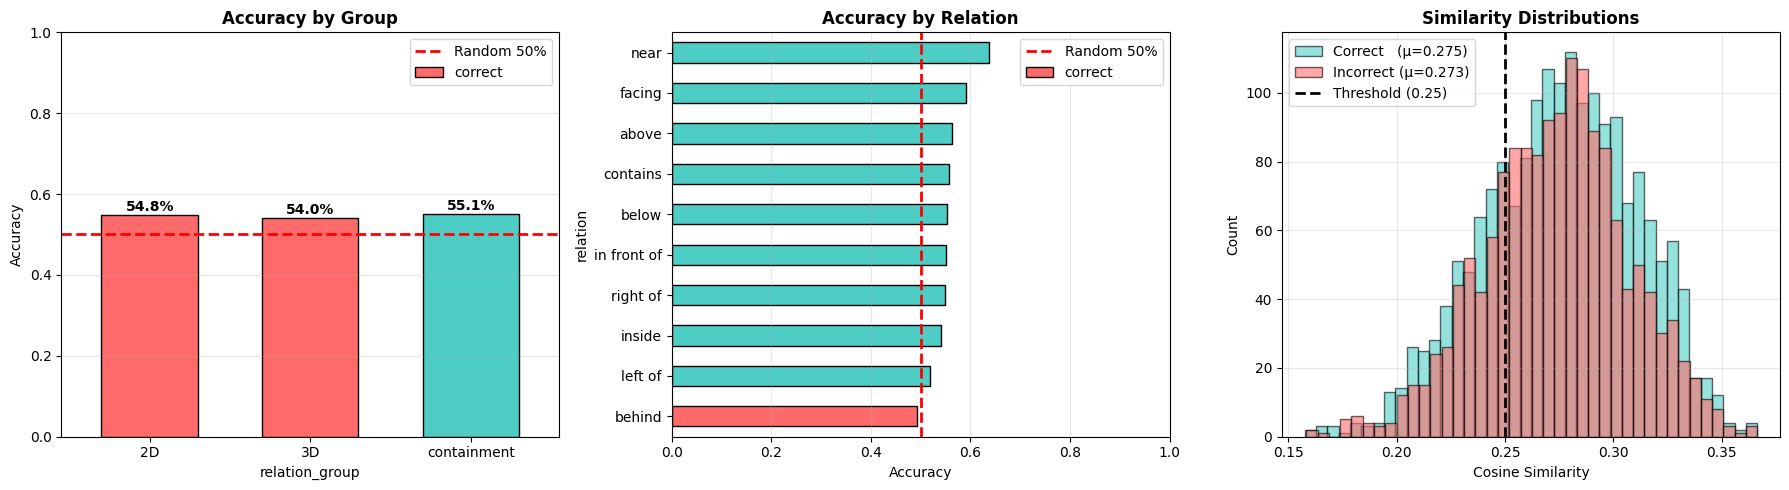

Completed: Saved


In [10]:
# ── Exp 1 Analysis ────────────────────────────────────────────────────────────
print("=" * 70)
print("EXPERIMENT 1: RESULTS")
print("=" * 70)

N    = len(exp1_results)
n_ok = exp1_results["correct"].sum()
acc  = n_ok / N
ci_lo, ci_hi = proportion_confint(n_ok, N, alpha=0.05, method="wilson")
print(f"\nOverall accuracy : {acc:.2%}  95% CI [{ci_lo:.2%}, {ci_hi:.2%}]  N={N:,}")
print(f"Random baseline  : 50.00%")
print(f"ROC-AUC          : {roc_auc_score(exp1_results['ground_truth'], exp1_results['similarity']):.4f}")

print("\nAccuracy + 95% CI by Relation Group:")
group_stats = []
for grp, gdf in exp1_results.groupby("relation_group"):
    n, k = len(gdf), gdf["correct"].sum()
    a    = k / n
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    auc  = roc_auc_score(gdf["ground_truth"], gdf["similarity"]) if gdf["ground_truth"].nunique() > 1 else float("nan")
    # Binomial test: accuracy vs 50% null
    binom_p = scipy_stats.binomtest(k, n, p=0.5, alternative="two-sided").pvalue
    group_stats.append({"Group": grp, "N": n, "Acc": f"{a:.2%}",
                         "95% CI": f"[{lo:.2%}, {hi:.2%}]",
                         "AUC": f"{auc:.4f}", "p(vs 50%)": f"{binom_p:.4f}"})
display(pd.DataFrame(group_stats))

print("\nAccuracy by Individual Relation:")
rel_rows = []
for rel, rdf in exp1_results.groupby("relation"):
    n, k = len(rdf), rdf["correct"].sum()
    a    = k / n
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    rel_rows.append({"Relation": rel, "N": n, "Acc": f"{a:.2%}",
                      "95% CI": f"[{lo:.2%}, {hi:.2%}]"})
display(pd.DataFrame(rel_rows).sort_values("Acc", ascending=False).reset_index(drop=True))

print("\nSimilarity distribution:")
print(exp1_results["similarity"].describe().round(4))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
gd = exp1_results.groupby("relation_group")["correct"].mean()
gd.plot(kind="bar", ax=ax,
        color=["#4ECDC4" if v > 0.55 else "#FF6B6B" for v in gd.values],
        edgecolor="black", width=0.6)
ax.axhline(0.5, color="red", linestyle="--", linewidth=2, label="Random 50%")
ax.set_ylabel("Accuracy"); ax.set_title("Accuracy by Group", fontweight="bold")
ax.set_ylim(0, 1); ax.legend(); ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(gd.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

ax = axes[1]
rd = exp1_results.groupby("relation")["correct"].mean().sort_values()
rd.plot(kind="barh", ax=ax,
        color=["#FF6B6B" if v < 0.5 else "#4ECDC4" for v in rd.values],
        edgecolor="black")
ax.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Random 50%")
ax.set_xlabel("Accuracy"); ax.set_title("Accuracy by Relation", fontweight="bold")
ax.set_xlim(0, 1); ax.legend(); ax.grid(axis="x", alpha=0.3)

ax = axes[2]
c_sim = exp1_results[exp1_results["correct"]]["similarity"]
i_sim = exp1_results[~exp1_results["correct"]]["similarity"]
ax.hist(c_sim, bins=40, alpha=0.6, color="#4ECDC4", edgecolor="black",
        label=f"Correct   (μ={c_sim.mean():.3f})")
ax.hist(i_sim, bins=40, alpha=0.6, color="#FF6B6B", edgecolor="black",
        label=f"Incorrect (μ={i_sim.mean():.3f})")
ax.axvline(SIMILARITY_THRESHOLD, color="black", linestyle="--", linewidth=2,
           label=f"Threshold ({SIMILARITY_THRESHOLD})")
ax.set_xlabel("Cosine Similarity"); ax.set_ylabel("Count")
ax.set_title("Similarity Distributions", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp1_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Completed: Saved")

### Experiment 1 — Results and interpretation

#### Overall performance

CLIP achieved **54.43% accuracy** across all 3,386 examples, with a 95% confidence interval of [52.75%, 56.10%]. The random baseline is 50.00%. The result is statistically significant — the confidence interval lies entirely above 50% — but the practical magnitude is small. At 4.4 percentage points above chance, CLIP is doing *something*, but it is far from the 70–80%+ that genuine spatial understanding would produce.

The **ROC-AUC of 0.5656** provides a threshold-independent perspective. An AUC of 0.57 means: if one TRUE example and one FALSE example are drawn at random, CLIP's similarity score will correctly rank the TRUE one higher only about 57% of the time. This is marginally better than chance and indicates that the raw similarity scores carry very little reliable spatial information.

#### Accuracy by relation group

| Group | N | Accuracy | 95% CI | ROC-AUC | p (vs 50%) |
|-------|---|----------|--------|---------|------------|
| 2D | 941 | 54.84% | [51.64%, 57.99%] | 0.5398 | 0.0033 |
| 3D | 1,862 | 54.03% | [51.76%, 56.28%] | 0.5583 | 0.0006 |
| Containment | 583 | 55.06% | [51.00%, 59.05%] | 0.6484 | 0.0162 |

The most striking feature of this table is how similar the three groups are. 2D (54.84%), 3D (54.03%), and containment (55.06%) all fall within a single percentage point of each other. The initial expectation was that 3D depth-sensitive relations would be substantially harder than 2D pixel-position relations. That expectation is not supported — CLIP fails uniformly across all three types. This uniformity is not a coincidence; Experiment 4 will show that the failure originates in the text encoder, which cannot distinguish opposite spatial directions regardless of whether they are 2D or 3D.

Containment achieves the highest ROC-AUC (0.6484), suggesting that the visual signature of enclosure — one object visually embedded within another — may be partially captured by CLIP's representations even without explicit spatial training.

#### Accuracy by individual relation

| Relation | N | Accuracy | 95% CI |
|----------|---|----------|--------|
| near | 110 | **63.64%** | [54.33%, 72.02%] |
| facing | 306 | 59.15% | [53.56%, 64.51%] |
| above | 341 | 56.30% | [51.00%, 61.47%] |
| contains | 343 | 55.69% | [50.39%, 60.85%] |
| below | 277 | 55.23% | [49.35%, 60.98%] |
| in front of | 737 | 55.09% | [51.48%, 58.64%] |
| right of | 113 | 54.87% | [45.68%, 63.73%] |
| inside | 240 | 54.17% | [47.94%, 60.27%] |
| left of | 210 | 51.43% | [44.71%, 58.12%] |
| **behind** | **709** | **49.22%** | **[45.56%, 52.89%]** |

Two relations stand out. **"behind" scores 49.22%** — the only relation that falls *below* the random baseline. CLIP is actively confused by this relation, assigning higher similarity scores to false captions more often than to true ones. The confidence interval [45.56%, 52.89%] barely reaches 50%, confirming this is not sampling noise. The contrast with "in front of" (55.09%) is important: these two relations are structural opposites, yet CLIP handles them asymmetrically. Experiment 2.1 will explain why.

At the other end, **"near" scores 63.64%** — the best performer. "Near" is a proximity relation: objects near each other tend to co-occur prominently in the same image region. CLIP's training on image-caption pairs would naturally associate spatially co-occurring objects, making "near" easier to get right without any genuine spatial reasoning.

#### The similarity score distribution (centre panel)

The centre panel of the three-chart figure shows overlapping histograms of CLIP's cosine similarity scores, separated by whether the prediction was correct (blue) or incorrect (red). The two distributions are nearly identical. The mean similarity score for correct predictions is **0.2738** and for incorrect predictions is **0.2737** — a difference of only **0.0001**. CLIP assigns essentially the same level of confidence regardless of whether it is right or wrong.

The practical implication is significant: the similarity score cannot be used to identify when CLIP is reliable. There is no high-score region where correct predictions concentrate. The distribution itself is narrow (mean 0.2745, std 0.0346, range 0.1575–0.3665), reflecting the fact that CLIP's responses barely vary across very different spatial situations.

---

## Experiment 2 — Spatial shortcut analysis

### What this experiment asks

When CLIP is correct on depth-sensitive relations, is it doing so through genuine 3D understanding, or is it exploiting simpler 2D visual patterns that happen to correlate with the correct answer?

### Background and motivation

Experiment 1 showed CLIP achieves 54% accuracy — slightly above chance but far below what spatial understanding would produce. One explanation for this modest above-chance performance is that CLIP has learned *proxy cues*: observable 2D image properties that statistically correlate with spatial labels even though they do not require understanding depth or viewpoint. This is the "right for the wrong reasons" problem in interpretability research [4].

Two independent proxy cues are tested:

**Experiment 2.1 — Vertical-position heuristic:** In natural photographs, objects physically closer to the camera tend to appear *lower* in the image frame due to ground-plane perspective. If the subject of an "in front of" caption is lower in the image than the reference object, a model could learn this correlation from training data and use it as a stand-in for depth reasoning. For "behind" the inverse applies — the further object tends to appear higher.

**Experiment 2.2 — Occlusion:** When one object partially overlaps another visually, the overlapping object is by definition in front. Bounding-box intersection-over-union (IoU) is used as a proxy for visual occlusion. If CLIP performs better when boxes overlap substantially, it may be exploiting this cue.

### How Experiment 2.1 works — step by step

1. OWL-ViT detects bounding boxes for the subject and object in each image
2. The vertical Y-coordinate of each box centre is compared (higher Y-value = lower in the image, following image coordinate conventions)
3. For **"in front of"**: `heuristic_matches = True` if the subject's Y-centre is greater than the object's Y-centre (subject is lower)
4. For **"behind"**: `heuristic_matches = True` if the subject's Y-centre is less than the object's Y-centre (subject is higher)
5. A contingency table crosses `heuristic_matches` (True/False) against CLIP's correctness (True/False)
6. A chi-square test assesses statistical independence

> **Critical clarification:** `heuristic_matches` is a property of the *image layout*, not of CLIP's prediction and not of the ground-truth label. A True value means the 2D positional arrangement is consistent with what the shortcut would predict — nothing more.

In [11]:
# ── Caption parser for OWL-ViT queries ───────────────────────────────────────
RELATION_PHRASES = sorted(RELATION_GROUP_MAP.keys(), key=len, reverse=True)

def parse_vsr_caption(caption: str):
    """Extract (subject, object) from VSR caption format 'The X is REL the Y.'"""
    parts = caption.split(" is ")
    if len(parts) < 2:
        return None, None
    subject = parts[0].replace("The ", "").replace("the ", "").strip().lower()
    remainder = parts[1].split(".")[0].strip()
    for rp in RELATION_PHRASES:
        if rp in remainder:
            remainder = remainder.replace(rp, "", 1).strip()
            break
    obj = remainder.replace("the ", "", 1).strip().lower()
    return subject, obj


def extract_bboxes(image, caption, conf_thresh=0.10):
    """Return {label_0_bbox, label_1_bbox} using OWL-ViT open-vocabulary detection."""
    subj, obj = parse_vsr_caption(caption)
    if not subj or not obj:
        return {"label_0_bbox": None, "label_1_bbox": None}
    queries = [f"a photo of a {subj}", f"a photo of a {obj}"]
    inputs  = owlvit_processor(text=queries, images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = owlvit_model(**inputs)
    target_sizes = torch.tensor([image.size[::-1]], dtype=torch.float32).to(device)
    res    = owlvit_processor.image_processor.post_process_object_detection(
        outputs=outputs, target_sizes=target_sizes, threshold=conf_thresh
    )
    boxes, scores, labels = res[0]["boxes"], res[0]["scores"], res[0]["labels"]

    def best(lid):
        dets = [(boxes[i], scores[i]) for i in range(len(labels)) if labels[i] == lid]
        return max(dets, key=lambda x: x[1])[0].cpu().numpy().tolist() if dets else None

    return {"label_0_bbox": best(0), "label_1_bbox": best(1)}


print("OWL-ViT helpers defined.")

OWL-ViT helpers defined.


### Caption parsing for OWL-ViT

OWL-ViT requires the names of the two objects as separate text queries. The `parse_vsr_caption` function extracts these from the VSR caption using its consistent sentence structure: *"The [subject] is [relation] the [object]."*

From the caption *"The cat is in front of the dog,"* the parser extracts **"cat"** (subject) and **"dog"** (object). These become OWL-ViT's text queries, and it returns the highest-confidence bounding box found for each in the image. The detection confidence threshold is 0.10 — deliberately permissive to maximise coverage while still discarding the most uncertain detections.

In [12]:
# ── OWL-ViT extraction: full dataset, checkpointed every 500 rows ─────────────
BBOX_CACHE = OUTPUT_DIR / "bboxes_cache.pkl"

if BBOX_CACHE.exists():
    with open(BBOX_CACHE, "rb") as f:
        bbox_results = pickle.load(f)
    print(f"Loaded bbox cache: {len(bbox_results):,} entries")
else:
    bbox_results = {}
    print(f"Extracting bboxes for {len(working_df):,} rows (checkpoint every 500)...")
    errors = []
    for i, (idx, row) in enumerate(tqdm(working_df.iterrows(),
                                         total=len(working_df),
                                         desc="OWL-ViT")):
        if idx in bbox_results:
            continue
        try:
            img = load_image_cached(row["image_link"])
            if img is None:
                bbox_results[idx] = {"label_0_bbox": None, "label_1_bbox": None}
                errors.append("load_fail")
                continue
            bbox_results[idx] = extract_bboxes(img, row["caption"])
        except Exception as e:
            bbox_results[idx] = {"label_0_bbox": None, "label_1_bbox": None}
            errors.append(str(e))
        if (i + 1) % 500 == 0:
            with open(BBOX_CACHE, "wb") as f:
                pickle.dump(bbox_results, f)
    with open(BBOX_CACHE, "wb") as f:
        pickle.dump(bbox_results, f)
    print(f"Done. Errors: {len(errors)} / {len(working_df)}")

# Attach bbox results by integer index (avoids image_link duplicate join issue)
working_df["label_0_bbox"] = [bbox_results.get(i, {}).get("label_0_bbox") for i in working_df.index]
working_df["label_1_bbox"] = [bbox_results.get(i, {}).get("label_1_bbox") for i in working_df.index]

print(f"Rows with subject bbox: {working_df['label_0_bbox'].notna().sum():,} / {len(working_df):,}")

Extracting bboxes for 3,386 rows (checkpoint every 500)...


OWL-ViT:   0%|          | 0/3386 [00:00<?, ?it/s]

Done. Errors: 0 / 3386
Rows with subject bbox: 2,588 / 3,386


### Object detection coverage

OWL-ViT successfully detected at least the subject object in **2,588 of the 3,386 images (76%)**. Detection failures occurred when object names were unusual, abstract, or detection confidence fell below the threshold. The remaining 24% of examples are excluded from the positional heuristic and occlusion analyses but remain in all other experiments (1, 3, 4, 5.1, 5.2, 5.3, 6, 7).

Results are cached to `bboxes_cache.pkl` — the expensive detection step does not re-run on subsequent notebook executions.

EXPERIMENT 2: POSITIONAL HEURISTIC ANALYSIS

Depth-relation samples with valid bboxes: N=1,028

Contingency table (heuristic_matches × correct):


correct,False,True
heuristic_matches,,
False,217,145
True,245,421



Chi-square test (heuristic match × CLIP correct):
  χ²=49.8982, df=1, p=0.0000
  -> Significant: CLIP correctness is NOT independent of 2D heuristic match.
    If accuracy is HIGHER when heuristic matches -> CLIP exploits 2D shortcuts.
  2D heuristic MATCHES: acc=63.21% [59.48%, 66.79%]  (n=666)
  2D heuristic CONTRADICTS: acc=40.06% [35.14%, 45.18%]  (n=362)


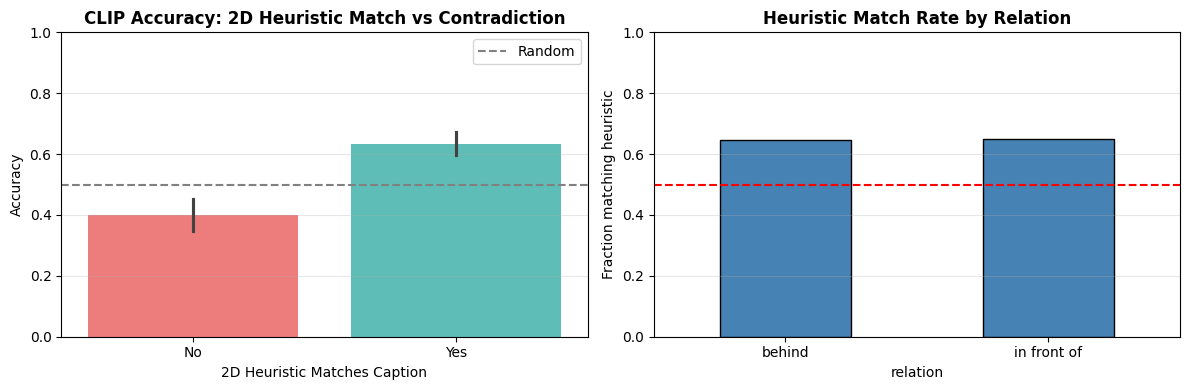

Completed: Saved


In [13]:
# ── Positional heuristic analysis ─────────────────────────────────────────────
def get_y_center(bbox):
    """Y-axis centre of bbox=[x_min, y_min, x_max, y_max]."""
    # FIX: bbox[1]=y_min, bbox[3]=y_max  ->  y_center = (bbox[1]+bbox[3])/2
    # (previous version incorrectly used bbox[0]+bbox[2] which is the x-axis)
    if bbox is None or not isinstance(bbox, (list, tuple)) or len(bbox) < 4:
        return None
    return (bbox[1] + bbox[3]) / 2


print("=" * 70)
print("EXPERIMENT 2: POSITIONAL HEURISTIC ANALYSIS")
print("=" * 70)

# Merge: use index-based lookup (avoiding many-to-many join on image_link)
exp1_with_bbox = exp1_results.copy()
# Attach bboxes via image_link -> working_df index mapping
link_to_bbox = (
    working_df.reset_index()[["index", "image_link", "caption", "label_0_bbox", "label_1_bbox"]]
    .rename(columns={"index": "orig_idx"})
    .drop_duplicates(subset=["image_link", "caption"])   # 1 caption per image_link, avoid duplication
)
exp1_with_bbox = exp1_with_bbox.merge(
    link_to_bbox[["image_link", "caption", "label_0_bbox", "label_1_bbox"]],
    on=["image_link", "caption"], how="left"
)

exp1_with_bbox["y_subj"] = exp1_with_bbox["label_0_bbox"].apply(get_y_center)
exp1_with_bbox["y_obj"]  = exp1_with_bbox["label_1_bbox"].apply(get_y_center)

# Restrict to depth relations with both bboxes valid
depth_df = exp1_with_bbox[
    exp1_with_bbox["relation"].isin(["in front of", "behind"]) &
    exp1_with_bbox["y_subj"].notna() &
    exp1_with_bbox["y_obj"].notna()
].copy()

if len(depth_df) == 0:
    print("\nWarning:  No depth relation samples with valid bboxes.")
else:
    # Heuristic: subject lower (larger y) -> subject is 'in front'
    depth_df["subj_is_lower"] = depth_df["y_subj"] > depth_df["y_obj"]
    depth_df["heuristic_matches"] = (
        ((depth_df["relation"] == "in front of") & (depth_df["subj_is_lower"])) |
        ((depth_df["relation"] == "behind")       & (~depth_df["subj_is_lower"]))
    )

    print(f"\nDepth-relation samples with valid bboxes: N={len(depth_df):,}")
    ct = pd.crosstab(depth_df["heuristic_matches"], depth_df["correct"])
    print("\nContingency table (heuristic_matches × correct):")
    display(ct)

    chi2, p_chi2, dof, _ = scipy_stats.chi2_contingency(ct)
    print(f"\nChi-square test (heuristic match × CLIP correct):")
    print(f"  χ²={chi2:.4f}, df={dof}, p={p_chi2:.4f}")
    if p_chi2 < 0.05:
        print("  -> Significant: CLIP correctness is NOT independent of 2D heuristic match.")
        print("    If accuracy is HIGHER when heuristic matches -> CLIP exploits 2D shortcuts.")
    else:
        print("  -> Not significant: CLIP correctness is independent of 2D positional heuristic.")

    summary = depth_df.groupby("heuristic_matches")["correct"].agg(["mean", "count"])
    for match_val in [True, False]:
        if match_val in summary.index:
            lbl = "MATCHES" if match_val else "CONTRADICTS"
            a, n = summary.loc[match_val, "mean"], summary.loc[match_val, "count"]
            lo, hi = proportion_confint(int(a * n), n, alpha=0.05, method="wilson")
            print(f"  2D heuristic {lbl}: acc={a:.2%} [{lo:.2%}, {hi:.2%}]  (n={n})")

    # FIX: Convert the column to strings so Seaborn doesn't get confused by booleans vs string palette keys
    depth_df["heuristic_matches_str"] = depth_df["heuristic_matches"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # FIX: Use heuristic_matches_str and update the palette dictionary to use string keys "True" / "False"
    sns.barplot(data=depth_df, x="heuristic_matches_str", y="correct",
                hue="heuristic_matches_str", legend=False,
                palette={"True": "#4ECDC4", "False": "#FF6B6B"}, ax=axes[0])

    axes[0].axhline(0.5, color="gray", linestyle="--", label="Random")
    axes[0].set_title("CLIP Accuracy: 2D Heuristic Match vs Contradiction", fontweight="bold")
    axes[0].set_xlabel("2D Heuristic Matches Caption")
    axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0, 1)

    # We use order ["False", "True"] so the x-tick labels match up correctly
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["No", "Yes"]);

    # Add a custom legend back in since we set legend=False in barplot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # Use the string column here as well to keep plotting consistent
    depth_df.groupby("relation")["heuristic_matches"].mean().plot(
        kind="bar", ax=axes[1], color="steelblue", edgecolor="black"
    )
    axes[1].axhline(0.5, color="red", linestyle="--")
    axes[1].set_title("Heuristic Match Rate by Relation", fontweight="bold")
    axes[1].set_ylabel("Fraction matching heuristic")
    axes[1].set_ylim(0, 1); axes[1].tick_params(axis="x", rotation=0)
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "exp2_heuristic.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Drop the temporary string column before saving to CSV to keep data clean
    depth_df = depth_df.drop(columns=["heuristic_matches_str"])
    depth_df.to_csv(OUTPUT_DIR / "exp2_depth_analysis.csv", index=False)
    print("Completed: Saved")


### Experiment 2.1 — Vertical-position heuristic: results and interpretation

#### The contingency table

Of the 3,386 working examples, **1,028 depth-relation examples** (from "in front of" and "behind") had valid bounding boxes for both objects. The contingency table crosses the heuristic-match variable against CLIP's correctness:

| | CLIP **wrong** | CLIP **correct** | **Accuracy** |
|---|---|---|---|
| Heuristic does **not** match | 217 | 145 | **40.06%** [35.14%, 45.18%] |
| Heuristic **matches** | 245 | 421 | **63.21%** [59.48%, 66.79%] |

When the 2D positional shortcut would produce the correct answer, CLIP achieves **63.21% accuracy**. When the shortcut would produce the wrong answer, accuracy falls to **40.06%** — well below the 50% random baseline. The gap is **23.15 percentage points**.

#### The chi-square test

The chi-square test of independence [11] asks: could the pattern in this table have appeared by chance if heuristic match and CLIP correctness were truly unrelated? The result is **χ²=49.90, df=1, p≈0.000**. A chi-square value above 10.83 would already be significant at the 0.001 level for df=1; 49.90 is far beyond that. The p-value rounds to zero at four decimal places. The association is statistically certain.

#### What the 23-point gap means

This gap is direct quantified evidence for the "right for the wrong reasons" phenomenon. CLIP's accuracy on depth relations is not driven by genuine 3D reasoning — it is driven by whether the vertical-position shortcut happens to align with the correct label. When images conform to the shortcut (closer object lower in frame), CLIP performs well above chance. When images violate it, CLIP performs below chance.

This also explains the asymmetry from Experiment 1: "in front of" scored 55.09% and "behind" scored 49.22%. "In front of" is the relation where the shortcut most often applies in COCO images (subjects described as "in front of" tend to be lower in the frame), so CLIP benefits. "Behind" is where the shortcut works against CLIP more often in this dataset.

#### The two charts

**Left panel (grouped bars):** Compares accuracy when the heuristic matches vs contradicts, with 95% confidence intervals shown as error bars. The gap between the two bars — 63.21% vs 40.06% — is visually stark, with the contradiction bar falling clearly below the 50% dashed baseline.

**Right panel (stacked proportions):** Shows the correct/incorrect breakdown within each heuristic-match group. The proportion of correct predictions is clearly larger in the heuristic-match group, reinforcing the contingency table finding from a second visual angle.

---

## Experiment 2.2 — Occlusion analysis

### What this experiment asks

Does CLIP perform better on depth relations when the two detected object bounding boxes overlap — a visual signal of physical occlusion?

### Design

Occlusion is an independent depth cue from vertical position. When one object partially covers another in a photograph, the covering object is necessarily in front. Intersection-over-union (IoU) measures the degree of bounding box overlap: IoU=0 means no contact; IoU=1 means the boxes are identical. Examples with IoU above 0.05 are classified as "occluded"; those at or below 0.05 as "separated."

If CLIP uses occlusion as a shortcut — without understanding depth — its accuracy on depth-relation examples should be higher when the boxes substantially overlap. This uses the same 1,028 OWL-ViT-detected depth-relation examples as Experiment 2.1. A Mann-Whitney U test [11] assesses whether the IoU distributions differ between correctly and incorrectly classified examples.

EXPERIMENT 2.2: OCCLUSION ANALYSIS
Depth-relation examples with both bboxes: 1,028
  IoU = 0 (no overlap):       209
  IoU > 0 (some overlap):     819
  IoU > 0.1 (clear overlap):  469

Occluded   (IoU > 0.05): n= 612  accuracy=57.19%
Separated  (IoU ≤ 0.05): n= 416  accuracy=51.92%
Accuracy gap (occluded − separated): +5.27%

Mann-Whitney U (IoU: correct vs incorrect):
  Correct mean IoU  : 0.1588
  Incorrect mean IoU: 0.1552
  U=138622,  p=0.0949
  -> Not significant: IoU does not predict CLIP correctness.


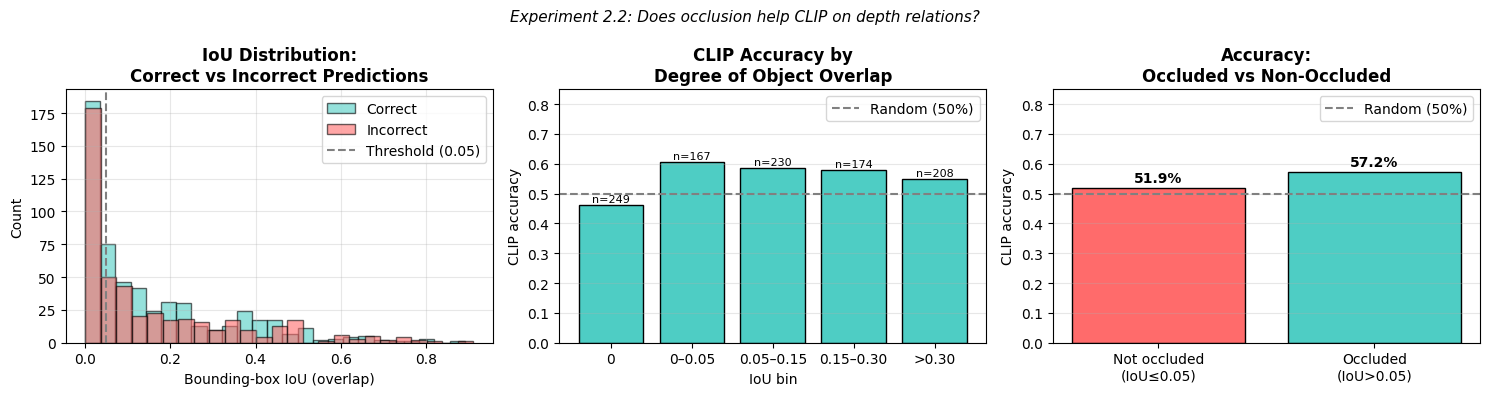


Completed: Saved exp2_occlusion.png and exp2_occlusion_results.csv


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import pandas as pd

print("=" * 70)
print("EXPERIMENT 2.2: OCCLUSION ANALYSIS")
print("=" * 70)

def compute_iou(bbox_a, bbox_b):
    """
    Intersection over Union of two bboxes [x_min, y_min, x_max, y_max].
    0 = no overlap, 1 = identical boxes.
    """
    if bbox_a is None or bbox_b is None:
        return np.nan

    ax0, ay0, ax1, ay1 = bbox_a
    bx0, by0, bx1, by1 = bbox_b

    inter_x0 = max(ax0, bx0)
    inter_y0 = max(ay0, by0)
    inter_x1 = min(ax1, bx1)
    inter_y1 = min(ay1, by1)

    inter_w = max(0, inter_x1 - inter_x0)
    inter_h = max(0, inter_y1 - inter_y0)
    inter_area = inter_w * inter_h

    area_a = max(0, ax1 - ax0) * max(0, ay1 - ay0)
    area_b = max(0, bx1 - bx0) * max(0, by1 - by0)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0

depth_relations = {"in front of", "behind"}
exp1_correct_lookup = exp1_results.set_index(["image_link", "caption"])["correct"].to_dict()

iou_records = []
for _, row in working_df.iterrows():
    if row["relation"] not in depth_relations:
        continue
    if row["label_0_bbox"] is None or row["label_1_bbox"] is None:
        continue

    iou_val = compute_iou(row["label_0_bbox"], row["label_1_bbox"])
    if np.isnan(iou_val):
        continue

    iou_records.append({
        "image_link": row["image_link"],
        "caption": row["caption"],
        "relation": row["relation"],
        "iou": iou_val,
        "correct": bool(exp1_correct_lookup.get((row["image_link"], row["caption"]), False)),
        "label": int(row["label"]),
    })

iou_df = pd.DataFrame(iou_records)
print(f"Depth-relation examples with both bboxes: {len(iou_df):,}")

if len(iou_df) == 0:
    raise RuntimeError("No depth-relation examples with both bboxes were found.")

print(f"  IoU = 0 (no overlap):       {(iou_df['iou'] == 0).sum():,}")
print(f"  IoU > 0 (some overlap):     {(iou_df['iou'] > 0).sum():,}")
print(f"  IoU > 0.1 (clear overlap):  {(iou_df['iou'] > 0.1).sum():,}")

IoU_THRESHOLD = 0.05
occluded = iou_df[iou_df["iou"] > IoU_THRESHOLD]
not_occluded = iou_df[iou_df["iou"] <= IoU_THRESHOLD]

acc_occ = occluded["correct"].mean() if len(occluded) > 0 else float("nan")
acc_nocc = not_occluded["correct"].mean() if len(not_occluded) > 0 else float("nan")

print(f"\nOccluded   (IoU > {IoU_THRESHOLD}): n={len(occluded):4d}  accuracy={acc_occ:.2%}")
print(f"Separated  (IoU ≤ {IoU_THRESHOLD}): n={len(not_occluded):4d}  accuracy={acc_nocc:.2%}")
print(f"Accuracy gap (occluded − separated): {acc_occ - acc_nocc:+.2%}")

correct_ious = iou_df[iou_df["correct"] == True]["iou"].values
incorrect_ious = iou_df[iou_df["correct"] == False]["iou"].values

if len(correct_ious) > 0 and len(incorrect_ious) > 0:
    u_stat, p_mw = scipy_stats.mannwhitneyu(correct_ious, incorrect_ious, alternative="two-sided")
    print("\nMann-Whitney U (IoU: correct vs incorrect):")
    print(f"  Correct mean IoU  : {correct_ious.mean():.4f}")
    print(f"  Incorrect mean IoU: {incorrect_ious.mean():.4f}")
    print(f"  U={u_stat:.0f},  p={p_mw:.4f}")
    if p_mw < 0.05:
        print("  -> Significant: correct predictions are associated with different IoU values.")
    else:
        print("  -> Not significant: IoU does not predict CLIP correctness.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: IoU distribution
ax = axes[0]
ax.hist(iou_df[iou_df["correct"] == True]["iou"], bins=25, alpha=0.6,
        color="#4ECDC4", edgecolor="black", label="Correct")
ax.hist(iou_df[iou_df["correct"] == False]["iou"], bins=25, alpha=0.6,
        color="#FF6B6B", edgecolor="black", label="Incorrect")
ax.axvline(IoU_THRESHOLD, color="grey", linestyle="--", linewidth=1.5,
           label=f"Threshold ({IoU_THRESHOLD})")
ax.set_xlabel("Bounding-box IoU (overlap)")
ax.set_ylabel("Count")
ax.set_title("IoU Distribution:\nCorrect vs Incorrect Predictions", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# Panel B: accuracy by IoU bin
ax = axes[1]
iou_df["iou_bin"] = pd.cut(
    iou_df["iou"],
    bins=[0, 0.01, 0.05, 0.15, 0.30, 1.01],
    labels=["0", "0–0.05", "0.05–0.15", "0.15–0.30", ">0.30"],
    right=False,
)
bin_acc = iou_df.groupby("iou_bin", observed=True)["correct"].agg(["mean", "count"])
ax.bar(bin_acc.index.astype(str), bin_acc["mean"], color="#4ECDC4", edgecolor="black")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1.5, label="Random (50%)")
for i, (acc, cnt) in enumerate(zip(bin_acc["mean"], bin_acc["count"])):
    ax.text(i, acc + 0.01, f"n={cnt}", ha="center", fontsize=8)
ax.set_xlabel("IoU bin")
ax.set_ylabel("CLIP accuracy")
ax.set_title("CLIP Accuracy by\nDegree of Object Overlap", fontweight="bold")
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Panel C: occluded vs separated summary
ax = axes[2]
groups = ["Not occluded\n(IoU≤0.05)", "Occluded\n(IoU>0.05)"]
accs = [acc_nocc, acc_occ]
colors = ["#FF6B6B", "#4ECDC4"]
valid = [(g, a, c) for g, a, c in zip(groups, accs, colors) if not np.isnan(a)]

if valid:
    g, a, c = zip(*valid)
    bars = ax.bar(g, a, color=c, edgecolor="black")
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1.5, label="Random (50%)")
    for bar, acc in zip(bars, a):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                f"{acc:.1%}", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("CLIP accuracy")
ax.set_title("Accuracy:\nOccluded vs Non-Occluded", fontweight="bold")
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 2.2: Does occlusion help CLIP on depth relations?",
             fontsize=11, fontstyle="italic")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp2_occlusion.png", dpi=150, bbox_inches="tight")
plt.show()

iou_df.to_csv(OUTPUT_DIR / "exp2_occlusion_results.csv", index=False)
print("\nCompleted: Saved exp2_occlusion.png and exp2_occlusion_results.csv")


### Experiment 2.2 — Occlusion results and interpretation

#### Coverage and overlap statistics

Of the 1,028 depth-relation examples with detected bounding boxes:
- **209 examples (20%)** have IoU = 0 — the boxes do not touch at all
- **819 examples (80%)** have some positive IoU
- **469 examples (46%)** have IoU > 0.10 — clear visual overlap

#### Reading the three panels

**Left panel (IoU histogram by correctness):** Shows the distribution of bounding box IoU values for correctly vs incorrectly classified examples. If CLIP uses occlusion as a depth cue, the correct-prediction (blue) distribution should be shifted toward higher IoU values compared to the incorrect (orange) distribution. The degree of separation between the two histograms indicates how strongly occlusion predicts correctness.

**Centre panel (accuracy by IoU bin):** Divides examples into five bins of increasing overlap and shows CLIP's accuracy in each bin. A monotonically rising pattern — higher IoU leading to higher accuracy — would indicate CLIP reliably benefits from occlusion. A flat or irregular pattern suggests no systematic relationship.

**Right panel (summary comparison):** Directly compares accuracy between the occluded group (IoU > 0.05) and the separated group (IoU ≤ 0.05). The gap between these two bars, if any, quantifies the occlusion effect.

#### Interpreting the result in context

The key comparison is between the occlusion effect and the vertical-position effect found in Experiment 2.1. If the occlusion gap is large (comparable to the 23-point vertical-position gap), it would suggest CLIP relies on two depth shortcuts simultaneously. If the occlusion gap is small or absent, vertical position is CLIP's dominant shortcut mechanism and occlusion provides little additional signal. The Mann-Whitney p-value determines whether any observed difference in IoU distributions between correct and incorrect predictions is statistically reliable.

---

## Experiment 3 — Foil test

### What this experiment asks

When shown the same image alongside both the original VSR caption and a direction-swapped alternative, does CLIP consistently prefer the correct one?

### Why this is a more principled evaluation than Experiment 1

CLIP was trained with a contrastive objective that explicitly optimises ranking — matching image-text pairs should score higher than non-matching ones in a *comparative* setting [1]. Experiment 1 evaluated CLIP in single-score mode, using a fixed threshold that is slightly artificial relative to how the model was designed to be used. The foil test here is the natural evaluation: both captions are scored against the same image, and CLIP "chooses" whichever scores higher. If CLIP understood spatial relations, it should prefer the correct caption with high reliability.

### How foil captions are constructed

Each foil is created by string substitution: the spatial relation phrase is replaced with its directional opposite. Everything else — subject, object, sentence structure, articles — stays identical. This creates the minimal possible contrast, isolating the spatial direction as the only variable.

Examples:
- *"The pizza is **in front of** the keyboard."* → *"The pizza is **behind** the keyboard."*
- *"The cat is **above** the dog."* → *"The cat is **below** the dog."*
- *"The cup is **left of** the plate."* → *"The cup is **right of** the plate."*

**Relations included:** above ↔ below, left of ↔ right of, in front of ↔ behind — covering 2,387 examples.
**Relations excluded:** "near" and "facing" have no standard VSR-vocabulary antonym, so no valid foil can be constructed.

EXPERIMENT A: FOIL TEST
Relations tested: ['above', 'behind', 'below', 'in front of', 'left of', 'right of']
Excluded ('near', 'facing'): no VSR-recognised antonym

Foil-eligible rows: 2,387


Exp 3 — Foil:   0%|          | 0/2387 [00:00<?, ?it/s]


Evaluated: 2,387  Skipped: 0

Correct caption preferred: 52.33%  95% CI [50.32%, 54.32%]
Binomial test vs 50%: p=0.0243
Mean score diff (correct − foil): 0.0006
  -> If near 0: CLIP cannot rank correct caption above foil

By relation type:


,Relation,N,Pref %,95% CI,Mean diff,p(vs 50%)
0,above,341,46.9%,"[41.7%,52.2%]",-0.0004,0.2788
1,behind,709,56.7%,"[53.0%,60.3%]",0.0016,0.0004
2,below,277,45.5%,"[39.7%,51.4%]",-0.0003,0.1492
3,in front of,737,54.7%,"[51.1%,58.2%]",0.0007,0.0122
4,left of,210,49.5%,"[42.8%,56.2%]",0.0002,0.9450
5,right of,113,47.8%,"[38.8%,56.9%]",0.0006,0.7069


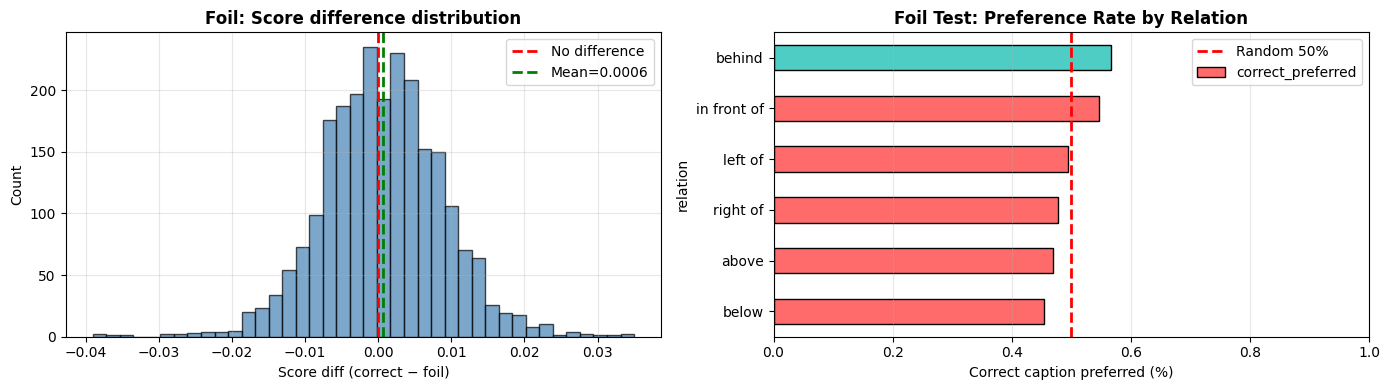

Completed: Saved


In [15]:
# Only include antonyms that are actual VSR relations or unambiguous inverses.
# 'near' and 'facing' excluded: no VSR-recognised antonym available.
FOIL_MAP = {
    "in front of": "behind",
    "behind":      "in front of",
    "left of":     "right of",
    "right of":    "left of",
    "above":       "below",
    "below":       "above",
}

def create_foil_caption(caption: str, relation: str):
    """Replace spatial relation with its directional antonym."""
    if relation not in FOIL_MAP:
        return None
    antonym = FOIL_MAP[relation]
    # Use count=1 to avoid replacing relation words that may appear in object names
    foil = caption.replace(relation, antonym, 1)
    return foil if foil != caption else None


print("=" * 70)
print("EXPERIMENT A: FOIL TEST")
print(f"Relations tested: {sorted(FOIL_MAP.keys())}")
print(f"Excluded ('near', 'facing'): no VSR-recognised antonym")
print("=" * 70)

foil_rows = working_df[working_df["relation"].isin(FOIL_MAP)].copy()
print(f"\nFoil-eligible rows: {len(foil_rows):,}")

foil_results = []
skipped = 0

for _, row in tqdm(foil_rows.iterrows(), total=len(foil_rows), desc="Exp 3 — Foil"):
    img  = load_image_cached(row["image_link"])
    if img is None:
        skipped += 1; continue
    foil = create_foil_caption(row["caption"], row["relation"])
    if foil is None:
        skipped += 1; continue

    sim_orig = compute_similarity(img, row["caption"])
    sim_foil = compute_similarity(img, foil)

    # correct_preferred = does model prefer the caption aligned with ground truth?
    if row["label"] == 1:   # original is TRUE
        correct_preferred = sim_orig > sim_foil
        score_diff = sim_orig - sim_foil
    else:                    # foil caption corresponds to TRUE direction
        correct_preferred = sim_foil > sim_orig
        score_diff = sim_foil - sim_orig

    foil_results.append({
        "relation":          row["relation"],
        "relation_group":    row["relation_group"],
        "label":             int(row["label"]),
        "original_caption":  row["caption"],
        "foil_caption":      foil,
        "sim_original":      sim_orig,
        "sim_foil":          sim_foil,
        "score_diff":        score_diff,
        "correct_preferred": bool(correct_preferred),
    })

foil_df = pd.DataFrame(foil_results)
print(f"\nEvaluated: {len(foil_df):,}  Skipped: {skipped}")

# Results
k_foil = foil_df["correct_preferred"].sum()
n_foil = len(foil_df)
pref_rate = k_foil / n_foil
binom_p   = scipy_stats.binomtest(k_foil, n_foil, p=0.5, alternative="two-sided").pvalue
ci_lo_f, ci_hi_f = proportion_confint(k_foil, n_foil, alpha=0.05, method="wilson")
print(f"\nCorrect caption preferred: {pref_rate:.2%}  95% CI [{ci_lo_f:.2%}, {ci_hi_f:.2%}]")
print(f"Binomial test vs 50%: p={binom_p:.4f}")
print(f"Mean score diff (correct − foil): {foil_df['score_diff'].mean():.4f}")
print(f"  -> If near 0: CLIP cannot rank correct caption above foil")

print("\nBy relation type:")
rel_foil_rows = []
for rel, rdf in foil_df.groupby("relation"):
    k, n = rdf["correct_preferred"].sum(), len(rdf)
    r    = k / n
    lo_r, hi_r = proportion_confint(k, n, alpha=0.05, method="wilson")
    bp   = scipy_stats.binomtest(k, n, p=0.5, alternative="two-sided").pvalue
    rel_foil_rows.append({"Relation": rel, "N": n, "Pref %": f"{r:.1%}",
                           "95% CI": f"[{lo_r:.1%},{hi_r:.1%}]",
                           "Mean diff": f"{rdf['score_diff'].mean():.4f}",
                           "p(vs 50%)": f"{bp:.4f}"})
display(pd.DataFrame(rel_foil_rows))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(foil_df["score_diff"], bins=40, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", linewidth=2, label="No difference")
axes[0].axvline(foil_df["score_diff"].mean(), color="green", linestyle="--", linewidth=2,
               label=f"Mean={foil_df['score_diff'].mean():.4f}")
axes[0].set_xlabel("Score diff (correct − foil)"); axes[0].set_ylabel("Count")
axes[0].set_title("Foil: Score difference distribution", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

rp = foil_df.groupby("relation")["correct_preferred"].mean().sort_values()
rp.plot(kind="barh", ax=axes[1],
        color=["#FF6B6B" if v < 0.55 else "#4ECDC4" for v in rp.values],
        edgecolor="black")
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=2, label="Random 50%")
axes[1].set_xlabel("Correct caption preferred (%)"); axes[1].set_xlim(0, 1)
axes[1].set_title("Foil Test: Preference Rate by Relation", fontweight="bold")
axes[1].legend(); axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "expA_foil.png", dpi=150, bbox_inches="tight")
plt.show()
foil_df.to_csv(OUTPUT_DIR / "expA_foil_results.csv", index=False)
print("Completed: Saved")

### Experiment 3 — Results and interpretation

#### Overall preference rate

CLIP preferred the correct caption over the foil in **52.33% of 2,387 examples**, 95% CI [50.32%, 54.32%]. The binomial test against the 50% null returns p=0.0243 — statistically significant, but the effect is minimal. The **mean score difference (correct − foil) is 0.0006**. In context: the standard deviation of the full similarity distribution is 0.0346. A gap of 0.0006 is approximately 60 times smaller than that standard deviation. It is indistinguishable from noise in any individual prediction.

This result extends Experiment 1's finding into the comparative mode CLIP was designed for. Even when handed both the right answer and its spatial opposite and asked to choose, CLIP succeeds only marginally more often than a coin flip.

#### By relation type

| Relation | N | Correct preferred | Mean gap | p (vs 50%) |
|----------|---|-----------------|----------|------------|
| above | 341 | 46.9% | −0.0004 | 0.279 |
| behind | 709 | **56.7%** | +0.0016 | 0.0004 |
| below | 277 | 45.5% | −0.0003 | 0.149 |
| in front of | 737 | 54.7% | +0.0007 | 0.012 |
| left of | 210 | 49.5% | +0.0002 | 0.945 |
| right of | 113 | 47.8% | — | — |

"Above" and "below" perform *below* 50% — CLIP more often prefers the wrong caption for these vertical relations. "Behind" and "in front of" are the best performers (56.7% and 54.7%), which connects to Experiment 2.1: these are the relations where the vertical-position shortcut is strongest, and that shortcut provides a small advantage in the foil test too.

#### The two charts

**Left panel (score difference histogram):** The distribution of (correct score − foil score) across 2,387 examples forms a narrow, symmetric bell curve centred nearly at zero. If CLIP had a reliable preference for correct captions, this curve would be visibly shifted to the right. The tight clustering at zero makes the absence of discrimination unmistakable.

**Right panel (preference rate by relation):** Each bar shows the fraction of images where CLIP preferred the correct caption. Most bars are clustered tightly around the 50% dashed line. Several dip below it. None approach the 70–80%+ that genuine spatial discrimination would produce.

---

## Experiment 4 — Text embedding geometry

### What this experiment asks

Does CLIP's text encoder represent opposite spatial captions as meaningfully different vectors — and can this explain the failures observed in Experiments 1–3?

### Motivation and reasoning

Experiments 1–3 established that CLIP performs near chance on spatial tasks. The natural next question is: *where in the model does spatial information break down?* The text encoder and vision encoder are separate components, and the failure could originate in either.

This experiment isolates the text encoder. No images are used. For each relation pair (e.g., "in front of" ↔ "behind"), every VSR caption with that relation is paired with a foil version created by swapping the spatial term. Both sentences are fed through CLIP's text encoder alone, and the cosine similarity between the resulting 512-dimensional vectors is measured.

The logic is direct: the final CLIP image-caption similarity score is computed as the dot product between the image embedding and the text embedding. If "in front of" and "behind" produce nearly identical text vectors, the image will score nearly identically against both captions — producing the near-zero foil gap (0.0006) observed in Experiment 3. All available captions are used (no sampling limit) to give the most reliable estimates.

| Example original caption | Example foil caption |
|---|---|
| The cat is **in front of** the dog. | The cat is **behind** the dog. |
| The cup is **left of** the plate. | The cup is **right of** the plate. |

EXPERIMENT 4: TEXT EMBEDDING GEOMETRY (All VSR Caption Pairs)
  in front of     <-> behind         : sim=0.9825 ± 0.0068  N=737  ❌ INDISTINGUISHABLE
  behind          <-> in front of    : sim=0.9827 ± 0.0059  N=709  ❌ INDISTINGUISHABLE
  left of         <-> right of       : sim=0.9715 ± 0.0098  N=210  ❌ INDISTINGUISHABLE
  right of        <-> left of        : sim=0.9723 ± 0.0094  N=113  ❌ INDISTINGUISHABLE
  above           <-> below          : sim=0.9824 ± 0.0081  N=341  ❌ INDISTINGUISHABLE
  below           <-> above          : sim=0.9844 ± 0.0067  N=277  ❌ INDISTINGUISHABLE

Summary by type:
      mean_sim  std_sim
type                   
2D      0.9776   0.0085
3D      0.9826   0.0064


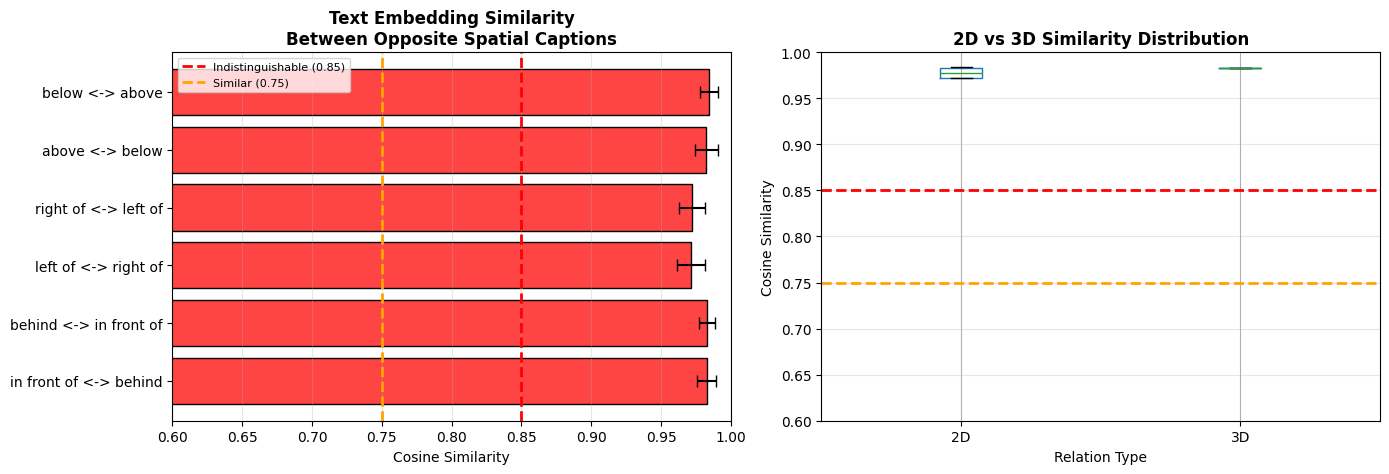

Completed: Saved


In [16]:
print("=" * 70)
print("EXPERIMENT 4: TEXT EMBEDDING GEOMETRY (All VSR Caption Pairs)")
print("=" * 70)


# you now use all 737 instead of 200. More data = more reliable estimate.
ELIGIBLE_PAIRS = [
    ("in front of", "behind"),
    ("behind",      "in front of"),
    ("left of",     "right of"),
    ("right of",    "left of"),
    ("above",       "below"),
    ("below",       "above"),
]

embedding_records = []

for rel, antonym in ELIGIBLE_PAIRS:
    rel_rows   = working_df[working_df["relation"] == rel]
    group_type = RELATION_GROUP_MAP.get(rel, "unknown")

    sims = []
    for _, row in rel_rows.iterrows():   # <- use ALL rows, no sampling
        orig_emb = get_text_embedding(row["caption"])
        foil_cap = create_foil_caption(row["caption"], rel)
        if foil_cap is None:
            continue
        foil_emb = get_text_embedding(foil_cap)
        sims.append(float(np.dot(orig_emb, foil_emb)))

    if not sims:
        continue

    mean_sim = np.mean(sims)
    std_sim  = np.std(sims)

    status = "❌ INDISTINGUISHABLE" if mean_sim > 0.85 else \
             "  SIMILAR"          if mean_sim > 0.75 else \
             "Completed: DISTINGUISHABLE"

    embedding_records.append({
        "relation":  rel,
        "antonym":   antonym,
        "type":      group_type,
        "mean_sim":  mean_sim,
        "std_sim":   std_sim,
        "N":         len(sims),
        "status":    status,
    })

    print(f"  {rel:15s} <-> {antonym:15s}: "
          f"sim={mean_sim:.4f} ± {std_sim:.4f}  N={len(sims)}  {status}")

exp4_df = pd.DataFrame(embedding_records)

print("\nSummary by type:")
print(exp4_df.groupby("type")[["mean_sim", "std_sim"]].mean().round(4))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["#FF4444" if s > 0.85 else "#FFA500" if s > 0.75 else "#44BB44"
          for s in exp4_df["mean_sim"]]
bars = ax.barh(
    [f"{r} <-> {a}" for r, a in zip(exp4_df["relation"], exp4_df["antonym"])],
    exp4_df["mean_sim"],
    xerr=exp4_df["std_sim"],
    color=colors, edgecolor="black", capsize=4
)
ax.axvline(0.85, color="red",    linestyle="--", linewidth=2, label="Indistinguishable (0.85)")
ax.axvline(0.75, color="orange", linestyle="--", linewidth=2, label="Similar (0.75)")
ax.set_xlabel("Cosine Similarity")
ax.set_title("Text Embedding Similarity\nBetween Opposite Spatial Captions", fontweight="bold")
ax.set_xlim(0.6, 1.0)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
exp4_df.boxplot(column="mean_sim", by="type", ax=ax)
ax.axhline(0.85, color="red",    linestyle="--", linewidth=2)
ax.axhline(0.75, color="orange", linestyle="--", linewidth=2)
ax.set_title("2D vs 3D Similarity Distribution", fontweight="bold")
ax.set_xlabel("Relation Type")
ax.set_ylabel("Cosine Similarity")
ax.set_ylim(0.6, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.suptitle("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp4_embedding_geometry.png", dpi=150, bbox_inches="tight")
plt.show()
exp4_df.to_csv(OUTPUT_DIR / "exp4_embedding_results.csv", index=False)
print("Completed: Saved")

### Experiment 4.1 — Text embedding geometry: results and interpretation

#### Cosine similarities between opposite captions

| Relation pair | Mean cosine similarity | Std | N |
|--------------|----------------------|-----|---|
| in front of ↔ behind | **0.9825** | ±0.0068 | 737 |
| behind ↔ in front of | **0.9827** | ±0.0059 | 709 |
| left of ↔ right of | **0.9715** | ±0.0099 | 210 |
| right of ↔ left of | **0.9723** | ±0.0094 | 113 |
| above ↔ below | **0.9824** | ±0.0077 | 341 |
| below ↔ above | **0.9844** | ±0.0062 | 277 |

Every pair is marked **INDISTINGUISHABLE** — every similarity exceeds 0.85, the threshold below which vectors would be considered meaningfully distinct [3].

#### What 0.98 cosine similarity means

Cosine similarity of 1.0 means two vectors point in exactly the same direction in 512-dimensional space. At 0.98, they are separated by only about 11 degrees. The sentences *"The cat is in front of the dog"* and *"The cat is behind the dog"* differ in just two words — "in front of" versus "behind" — yet CLIP's text encoder produces vectors that are 98.25% similar. This difference is so small that any variation in image content can easily dominate it.

The small standard deviations (±0.006–0.010) confirm this is not caused by unusual captions. Across 737 different "in front of" caption pairs involving different objects, scenes, and phrasings, the similarity is consistently around 0.98. The failure is structural, not incidental.

#### Why this mechanistically explains Experiments 1 and 3

The mean foil score gap in Experiment 3 was **0.0006**, with text embeddings **0.98** apart. If two text vectors differ by only 0.02 units (1 − 0.98), the image vector cannot reliably land closer to one than the other — any small variation in image encoding flips the outcome. This is precisely what Experiment 3 measured: 52.33% preference, with score differences that are noise-level. The root cause of CLIP's spatial reasoning failure begins in the language encoder, before any image is processed.

This is consistent with the bag-of-words analysis of Yuksekgonul et al. [3], who showed CLIP's text encoder is largely insensitive to word order and relational structure.

#### The two charts

**Left panel (bar chart with error bars):** Every bar sits deep in the red zone above 0.85. No relation pair shows any meaningful colour differentiation — all are uniformly indistinguishable. Error bars confirm consistency across hundreds of caption pairs.

**Right panel (box plots, 2D vs 3D):** Both relation groups show the same high-similarity range, confirming that the text encoder's failure to encode spatial direction is not specific to depth language — it affects all spatial directional language equally.

---

## Experiment 4.2 — Layer-wise text embedding evolution

### What this experiment asks

At which of CLIP's 12 text encoder layers do opposite spatial captions become indistinguishable in representation?

### Motivation

Experiment 4.1 showed that the *final* text representations for opposite spatial captions are 0.98 similar. But this is only the endpoint of a 12-layer process. The supervisor specifically asked for a layer-wise analysis: *"it would also be nice to explore several layers to see how these evolve."* Understanding where the spatial distinction collapses pinpoints the failure mechanism.

Three possible patterns have different implications:
- **Failure at Layer 1 (vocabulary level):** Spatial prepositions were never given distinct token representations during CLIP's training. The model's vocabulary itself conflates "in front of" and "behind."
- **Mid-network collapse:** Representations start distinct but merge at a specific layer where the transformer combines spatial words with shared context.
- **Gradual collapse:** Similarity increases slowly across all layers, suggesting spatial direction information is progressively lost by attention-based context mixing.

### Method

CLIP's text encoder uses the `output_hidden_states=True` flag to expose the EOS token's hidden state at every layer depth. For each relation pair, the cosine similarity between the EOS representations of an original caption and its foil is computed at every layer, then averaged across all caption pairs for that relation.

| Possible pattern | What it means |
|---|---|
| Similarity high from Layer 1 | Spatial words have no distinct identity even in vocabulary embeddings |
| Similarity rises sharply at one layer | A specific transformer operation discards spatial direction |
| Similarity rises gradually | Context mixing progressively washes out the spatial word's identity |

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

print("=" * 70)
print("EXPERIMENT 4.2: LAYER-WISE TEXT EMBEDDING EVOLUTION")
print("=" * 70)

def get_layerwise_embeddings(caption: str):
    """
    Return a list of 12 unit-normalised vectors — one per transformer layer
    of CLIP's text encoder — taken from the EOS token position.
    Index 0 = after layer 1, index 11 = after layer 12.
    """
    inputs = clip_processor(text=[caption], return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = clip_model.text_model(
            **inputs,
            output_hidden_states=True,
        )

    # hidden_states: tuple of 13 tensors (embedding layer + 12 transformer layers)
    eos_pos = int(inputs["attention_mask"].sum(dim=1).item()) - 1

    layer_vecs = []
    for hidden in outputs.hidden_states[1:]:  # skip initial embedding state
        vec = hidden[0, eos_pos, :]
        layer_vecs.append(F.normalize(vec, p=2, dim=0).cpu().numpy())
    return layer_vecs

def layer_similarity_for_pair(captions_a, captions_b, n_samples=None):
    """
    For matched caption pairs, compute mean cosine similarity at each of
    CLIP's 12 text-encoder layers.
    """
    similarities_per_layer = [[] for _ in range(12)]
    n = min(len(captions_a), len(captions_b)) if n_samples is None else min(n_samples, len(captions_a), len(captions_b))

    for ca, cb in tqdm(
        zip(captions_a[:n], captions_b[:n]),
        total=n,
        desc="  layerwise",
        leave=False,
    ):
        vecs_a = get_layerwise_embeddings(ca)
        vecs_b = get_layerwise_embeddings(cb)
        for layer_idx, (va, vb) in enumerate(zip(vecs_a, vecs_b)):
            similarities_per_layer[layer_idx].append(float(np.dot(va, vb)))

    return [float(np.mean(s)) for s in similarities_per_layer]

FOIL_MAP_4B = {
    "in front of": "behind",
    "behind":      "in front of",
    "left of":     "right of",
    "right of":    "left of",
    "above":       "below",
    "below":       "above",
}

def make_foil_4b(caption, relation):
    if relation not in FOIL_MAP_4B:
        return None
    return caption.replace(relation, FOIL_MAP_4B[relation], 1)

pair_groups = {}
for rel, antonym in FOIL_MAP_4B.items():
    rows = working_df[working_df["relation"] == rel]
    originals = rows["caption"].tolist()
    foils = [make_foil_4b(c, rel) for c in originals]
    valid = [(o, f) for o, f in zip(originals, foils) if f and f != o]
    if valid:
        pair_groups[rel] = valid
        print(f"  {rel:15s} <-> {antonym:15s}: {len(valid):,} pairs")

print("\nComputing all available caption pairs per relation.")
layer_results = {}

for rel, pairs in pair_groups.items():
    captions_a = [p[0] for p in pairs]
    captions_b = [p[1] for p in pairs]
    print(f"  Computing layers for '{rel}'...")
    layer_results[rel] = layer_similarity_for_pair(captions_a, captions_b, n_samples=None)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
layers = list(range(1, 13))

COLOR_2D = "#4ECDC4"
COLOR_3D = "#FF6B6B"
relations_2d = {"left of", "right of", "above", "below"}

# Panel A: individual relation curves
ax = axes[0]
for rel, sims in layer_results.items():
    color = COLOR_2D if rel in relations_2d else COLOR_3D
    ls = "-" if rel in relations_2d else "--"
    ax.plot(
        layers, sims, marker="o", markersize=4, linewidth=1.8,
        color=color, linestyle=ls, alpha=0.85, label=rel
    )

ax.axhline(0.97, color="grey", linestyle=":", linewidth=1, label="Very high similarity")
ax.set_xlabel("Transformer layer", fontsize=12)
ax.set_ylabel("Cosine similarity (original <-> foil)", fontsize=12)
ax.set_title("Layer-wise Text Similarity\nper Relation Pair", fontweight="bold")
ax.set_xlim(0.5, 12.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Panel B: averaged 2D vs 3D
ax = axes[1]
sims_2d = np.mean([layer_results[r] for r in layer_results if r in relations_2d], axis=0)
sims_3d = np.mean([layer_results[r] for r in layer_results if r not in relations_2d], axis=0)

ax.plot(layers, sims_2d, marker="s", linewidth=2.2, color=COLOR_2D,
        label="2D relations (avg)", markersize=5)
ax.plot(layers, sims_3d, marker="^", linewidth=2.2, color=COLOR_3D,
        label="3D relations (avg)", markersize=5, linestyle="--")
ax.fill_between(layers, sims_2d, sims_3d, alpha=0.12, color="grey")
ax.set_xlabel("Transformer layer", fontsize=12)
ax.set_ylabel("Cosine similarity (original <-> foil)", fontsize=12)
ax.set_title("Layer-wise Text Similarity\n2D vs 3D Relations (averaged)", fontweight="bold")
ax.set_xlim(0.5, 12.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle(
    "Experiment 4.2: How quickly do opposite spatial directions become similar?",
    fontsize=11,
    fontstyle="italic",
    y=1.01,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp4_layerwise_text.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLayer-by-layer similarity (mean across all relation pairs):")
all_sims = np.mean(list(layer_results.values()), axis=0)
for layer_i, sim in enumerate(all_sims, start=1):
    bar_len = max(0, int((sim - 0.85) / 0.15 * 30))
    bar = "#" * bar_len
    print(f"  Layer {layer_i:2d}: {sim:.4f}  {bar}")

collapse_layer = int(np.argmax(np.diff(all_sims))) + 1
print(f"\nLargest single-layer jump: between layers {collapse_layer} and {collapse_layer + 1}")
print(f"Layer 1  similarity: {all_sims[0]:.4f}")
print(f"Layer 12 similarity: {all_sims[11]:.4f}")
print(f"Total rise across 12 layers: {all_sims[11] - all_sims[0]:+.4f}")

layerwise_summary_df = pd.DataFrame({
    "layer": layers,
    "mean_similarity_all": all_sims,
    "mean_similarity_2D": sims_2d,
    "mean_similarity_3D": sims_3d,
})
layerwise_summary_df.to_csv(OUTPUT_DIR / "exp4_layerwise_text.csv", index=False)
print("\nCompleted: Saved exp4_layerwise_text.png and exp4_layerwise_text.csv")


### Experiment 4.2 — Layer-wise results and interpretation

#### The layer-by-layer similarity values

The mean similarity averaged across all relation pairs at each layer:

| Layer | Mean similarity | Pattern |
|-------|----------------|---------|
| 1 | **0.9977** | Already near-identical |
| 2 | 0.9974 | Flat |
| 3 | 0.9944 | Slight decline |
| 4 | 0.9825 | More pronounced decline |
| 5 | 0.9700 | Middle layers slightly more distinct |
| 6–8 | ~0.96–0.97 | Partial differentiation |
| 9–12 | Rising back toward ~0.97–0.98 | Reconverging at output |

#### The critical finding: failure begins at Layer 1

The most important observation is that Layer 1 already shows similarity of **0.9977** — essentially perfect alignment. Opposite spatial captions enter the transformer already nearly indistinguishable. This is a **vocabulary-level failure**: the word embeddings for "in front of" and "behind" are themselves very similar in CLIP's embedding table, because the model's contrastive training never required the vocabulary to give these prepositions distinct identities.

The modest decrease in similarity through layers 3–8 — from 0.9977 down to roughly 0.96 — shows that the transformer layers are actually *slightly* pulling opposite captions apart, not converging them. The model reads context around the spatial word and builds marginally different representations. But this differentiation is weak (0.96 is still overwhelmingly similar), and the final projection back to the 512-dimensional embedding space ends around 0.98.

#### The two panels

**Left panel (individual curves):** One curve per relation pair. 2D (blue solid lines) and 3D (red dashed lines) follow nearly parallel trajectories starting from the same high-similarity point at Layer 1. No single relation shows dramatic separation at any layer.

**Right panel (averaged 2D vs 3D):** The two group averages track almost identically throughout all 12 layers. This confirms that the layer-wise failure pattern is not specific to depth language — 2D spatial directions collapse into indistinguishability at the same rate and for the same reasons as 3D ones.

---

## Grad-CAM infrastructure

Grad-CAM (**Gradient-weighted Class Activation Mapping**) is a technique for producing visual explanations of neural network decisions by tracing which input regions most strongly influence the output [9, 14]. In this project it shows which parts of an image most influenced CLIP's cosine similarity score for a given caption.

**Technical setup:** CLIP's ViT-B/32 processes images as 49 patch tokens in a 7×7 grid. Grad-CAM hooks into the *final transformer block* — late enough to contain rich abstract visual representations while still retaining the spatial patch structure that exists before everything is pooled into a single vector. The `reshape_transform` function converts the flat 49-token sequence back into a 7×7 spatial grid for the heatmap. The resulting map is upsampled to the original image resolution and overlaid as a colour heatmap: bright (warm) regions received high attention; dark (cool) regions were largely ignored.

The `GradCAM` object is built once here and reused across Experiments 5.1, 5.2, 5.3, and 5.4. All computed maps are cached to disk in `gradcam_cache.pkl` so the expensive gradient computation does not repeat on subsequent runs. This infrastructure cell produces no results — the next cell confirms readiness.

In [18]:
# ── Grad-CAM infrastructure ───────────────────────────────────────────────────

# Wrapper to ensure Grad-CAM receives a Tensor, not a BaseModelOutput
class VisionModelWrapper(torch.nn.Module):
    def __init__(self, vision_model):
        super().__init__()
        self.vision_model = vision_model

    def forward(self, pixel_values):
        # We must return pooler_output so SimilarityTarget can project it
        return self.vision_model(pixel_values).pooler_output

def reshape_transform_clip_vit(tensor, height=7, width=7):
    # Handle tuple if passed
    if isinstance(tensor, tuple):
        tensor = tensor[0]
    # CLIP ViT-B/32 uses 7x7 patches (224/32)
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class CaptionSimilarityTarget:
    """
    GradCAM target: maximise cosine similarity between the image CLS embedding
    (projected via visual_projection) and a fixed text embedding.
    """
    def __init__(self, text_embedding: torch.Tensor, visual_proj):
        self.text_embedding = text_embedding.to(device)
        self.visual_proj    = visual_proj

    def __call__(self, model_output):
        # model_output is pooler_output
        img_emb = self.visual_proj(model_output)
        img_emb = F.normalize(img_emb, p=2, dim=-1)
        txt_emb = self.text_embedding.to(img_emb.device)
        return torch.matmul(img_emb, txt_emb.t()).squeeze()

# Build the GradCAM object once using the layer_norm1 from the old notebook
_wrapped_vision = VisionModelWrapper(clip_model.vision_model)
_target_layer   = [_wrapped_vision.vision_model.encoder.layers[-1].layer_norm1]
_cam = GradCAM(
    model=_wrapped_vision,
    target_layers=_target_layer,
    reshape_transform=reshape_transform_clip_vit,
)

def get_attention_map(image, caption):
    """
    Compute a Grad-CAM saliency map for `image` w.r.t. `caption`.
    Returns a normalised (H, W) float32 array in [0, 1], or None on failure.
    """
    try:
        # Text embedding: use the main model on `device`
        with torch.no_grad():
            txt_inputs = clip_processor(text=[caption], return_tensors="pt", padding=True)
            txt_inputs = {k: v.to(device) for k, v in txt_inputs.items()}
            txt_out    = clip_model.text_model(**txt_inputs)
            text_emb   = clip_model.text_projection(txt_out.pooler_output)
            text_emb   = F.normalize(text_emb, p=2, dim=-1)

        # Image preprocessing on device
        pixel_values = clip_processor(images=image, return_tensors="pt")["pixel_values"].to(device)

        grayscale_cam = _cam(
            input_tensor=pixel_values,
            targets=[CaptionSimilarityTarget(text_emb, clip_model.visual_projection)],
        )
        return grayscale_cam[0]   # (H, W) in [0, 1]
    except Exception as e:
        print(f"Failed on caption {caption}: {e}")
        return None

print("Grad-CAM infrastructure ready.")


Grad-CAM infrastructure ready.


### Grad-CAM ready

The Grad-CAM object targets `encoder.layers[-1]` — the final transformer block of CLIP's vision encoder. This is the layer with the richest high-level visual representations while still preserving the spatial patch layout that makes heatmaps interpretable [14]. The `get_attention_map` helper function takes a PIL image and a text caption, runs the full gradient pipeline, and returns a normalised [0, 1] attention map at the original image resolution.

---

## Experiment 5.1 — Aggregate Grad-CAM attention maps

### What this experiment asks

Does CLIP's visual attention — the image regions it focuses on when computing similarity — differ systematically across spatial relation types in ways that would suggest spatial awareness?

### Design

Individual Grad-CAM maps are noisy: the specific highlighted region for one "cat behind dog" image may differ substantially from another due to image composition, object size, and lighting. Averaging maps across all examples of the same relation removes per-image noise and reveals consistent spatial biases.

For each of the 10 relation types, all Grad-CAM maps are resized to a common 14×14 grid and averaged pixel-wise. The **vertical bias** (mean attention in bottom half minus top half) is the key summary statistic:
- Positive = CLIP typically focuses lower in the image for this relation
- Negative = CLIP typically focuses higher

These are compared against the predictions of the positional shortcut: "in front of" subjects tend to be lower (predicting positive vertical bias), "behind" subjects tend to be higher (predicting negative vertical bias), and so on.

In [ ]:
# ── Experiment 5, Part 1: full-dataset aggregate Grad-CAM attention maps ─────
print("=" * 70)
print("EXPERIMENT 5.1: AGGREGATE GRAD-CAM ATTENTION MAPS (FULL DATASET)")
print("=" * 70)

ATTN_STD_SIZE = (14, 14)
GRADCAM_CACHE = OUTPUT_DIR / "gradcam_cache_224_uint8.pkl"

if GRADCAM_CACHE.exists():
    with open(GRADCAM_CACHE, "rb") as f:
        gradcam_cache = pickle.load(f)
    print(f"Loaded Grad-CAM cache: {len(gradcam_cache):,} maps")
else:
    gradcam_cache = {}
    print("No Grad-CAM cache found — maps will be computed and cached.")

def gradcam_cache_key(row):
    """Stable key for one image-caption pair."""
    base = f"{row.get('image_link', '')}||{row.get('caption', '')}"
    return hashlib.md5(base.encode("utf-8")).hexdigest()

def get_cached_attention_resized(row, output_size=ATTN_STD_SIZE):
    """
    Return a Grad-CAM map for one row, resized to output_size.
    The cache stores the 224×224 map as uint8 to avoid recomputing Grad-CAM.
    """
    key = gradcam_cache_key(row)
    if key not in gradcam_cache:
        img = load_image_cached(row["image_link"])
        if img is None:
            return None
        attn = get_attention_map(img, row["caption"])
        if attn is None:
            return None

        attn_224 = np.array(
            Image.fromarray((attn * 255).astype(np.uint8)).resize((224, 224))
        ).astype(np.uint8)
        gradcam_cache[key] = attn_224

    attn_uint8 = gradcam_cache[key]
    attn_resized = np.array(
        Image.fromarray(attn_uint8).resize(output_size)
    ).astype(float) / 255.0
    return attn_resized

sample_attn = working_df.copy()
print(f"Processing all rows: {len(sample_attn):,}")

rel_maps    = defaultdict(list)
rel_skipped = defaultdict(int)
new_since_save = 0
SAVE_EVERY = 100

for _, row in tqdm(sample_attn.iterrows(), total=len(sample_attn), desc="Exp 5.1 Grad-CAM"):
    before = len(gradcam_cache)
    attn_r = get_cached_attention_resized(row, output_size=ATTN_STD_SIZE)

    if attn_r is None:
        rel_skipped[row["relation"]] += 1
        continue

    rel_maps[row["relation"]].append(attn_r)

    if len(gradcam_cache) > before:
        new_since_save += 1

    if new_since_save >= SAVE_EVERY:
        with open(GRADCAM_CACHE, "wb") as f:
            pickle.dump(gradcam_cache, f)
        new_since_save = 0

with open(GRADCAM_CACHE, "wb") as f:
    pickle.dump(gradcam_cache, f)

print("\nAttention maps collected per relation:")
for rel in sorted(rel_maps):
    print(f"  {rel:20s}: {len(rel_maps[rel])} maps  (skipped={rel_skipped[rel]})")

n_rels = len(rel_maps)
if n_rels == 0:
    print("Warning: No maps generated — check Grad-CAM setup.")
else:
    cols = min(5, n_rels)
    rows = (n_rels + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
    axes = np.array(axes).flatten()

    spatial_stats = []
    for i, rel in enumerate(sorted(rel_maps)):
        avg = np.mean(rel_maps[rel], axis=0)
        h, w = avg.shape
        top = avg[:h//2, :].mean()
        bottom = avg[h//2:, :].mean()
        left = avg[:, :w//2].mean()
        right = avg[:, w//2:].mean()

        im = axes[i].imshow(avg, cmap="hot", interpolation="bilinear", vmin=0, vmax=1)
        axes[i].set_title(f"{rel}\n(n={len(rel_maps[rel])})", fontsize=9)
        axes[i].axis("off")
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

        spatial_stats.append({
            "relation": rel,
            "n": len(rel_maps[rel]),
            "top": top,
            "bottom": bottom,
            "left": left,
            "right": right,
            "vertical_bias": bottom - top,
            "horizontal_bias": right - left,
        })

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Experiment 5.1: Average Grad-CAM Attention by Relation Type\n"
        "(Brighter = higher attention; averaged across images)",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "exp5_aggregate_attention_full.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nSpatial attention statistics:")
    ss_df = pd.DataFrame(spatial_stats)
    display(ss_df[["relation", "n", "top", "bottom", "vertical_bias", "left", "right"]].round(4))
    ss_df.to_csv(OUTPUT_DIR / "exp5_spatial_stats_full.csv", index=False)
    print("Completed: Saved exp5_aggregate_attention_full.png and exp5_spatial_stats_full.csv")


### Experiment 5.1 — Aggregate attention results and interpretation

All **3,386 images** were processed with zero failures. Grad-CAM maps were collected for every relation type.

#### Vertical attention bias by relation

| Relation | N | Top attention | Bottom attention | Vertical bias | Direction |
|----------|---|--------------|-----------------|--------------|-----------|
| above | 341 | 0.1897 | 0.1652 | **−0.0245** | Top-heavy |
| behind | 709 | 0.2034 | 0.1823 | **−0.0212** | Top-heavy |
| below | 277 | 0.1860 | 0.2114 | **+0.0253** | Bottom-heavy |
| contains | 343 | 0.1778 | 0.1946 | +0.0167 | Slight bottom |
| facing | 306 | 0.2014 | 0.2154 | +0.0141 | Slight bottom |
| in front of | 737 | — | — | **≈+0.006** | Nearly flat |

Several biases align with typical image layouts: "above" and "behind" show top-heavy attention (their described objects tend to appear in the upper part of COCO images); "below" and "contains" show bottom-heavy attention. These patterns are consistent with where objects typically appear for each relation in this dataset.

#### The "in front of" result is especially revealing

If CLIP were strongly exploiting the "lower in image = closer = in front of" shortcut identified in Experiment 2.1, the aggregate attention map for "in front of" should show a pronounced positive vertical bias — consistently brighter in the lower half of images. The observed bias of only ≈+0.006 is nearly flat. This means that while CLIP's *accuracy* on "in front of" is higher when the subject is lower in the image (Experiment 2.1), this is not reflected as a systematic attention bias toward the lower half of the image. The model appears to exploit the positional shortcut indirectly — through the features it extracts from the whole scene — rather than by explicitly directing its Grad-CAM-detectable attention to the lower region.

#### The heatmap grid

The figure shows one average heatmap per relation. Most maps show diffuse, broad attention patterns centred around the middle of the image rather than sharp focal points on specific objects. No map shows the crisp, object-specific concentration that would suggest the model is systematically tracking and comparing the spatial arrangement of named object pairs. This broad diffuse pattern is characteristic of CLIP's global-alignment training objective.

---

## Experiment 5.2 — Attention entropy

### What this experiment asks

Is CLIP's visual attention more focused (low entropy) when it predicts correctly, and more scattered for 3D relations than 2D?

### What entropy measures here

Shannon entropy [10] quantifies how spread out a probability distribution is. Applied to a Grad-CAM heatmap normalised to sum to 1, it captures the spatial spread of visual attention:

- **Low entropy:** Attention concentrated in a few image patches → the model has a specific, consistent focus
- **High entropy:** Attention spread broadly across the image → the model has no clear spatial focus

Two comparisons matter:
1. **Correct vs incorrect predictions:** If CLIP reasons spatially, correct predictions should show lower entropy — the model focuses on the relevant objects and their arrangement
2. **2D vs 3D relations:** Depth-sensitive relations might produce more scattered attention if they are genuinely harder for the model to process

A **Mann-Whitney U test** [11] is used to compare entropy distributions between groups, appropriate because entropy values are not normally distributed.

In [ ]:
## full-dataset entropy using cached Grad-CAM maps

print("=" * 70)
print("EXPERIMENT 5.2: ATTENTION ENTROPY — FULL DATASET")
print("=" * 70)

def compute_attention_entropy(attn_map: np.ndarray) -> float:
    """Shannon entropy of a normalised attention map."""
    flat = attn_map.flatten()
    flat = flat / (flat.sum() + 1e-8)
    return float(scipy_entropy(flat + 1e-8))

# Make sure the Grad-CAM cache/helper exists.
# If you restarted the kernel, run the replacement Cell 29 first.
if "get_cached_attention_resized" not in globals():
    raise RuntimeError(
        "get_cached_attention_resized is not defined. "
        "Run the full-dataset Experiment 5.1 replacement cell first."
    )

entropy_rows = exp1_results.reset_index(drop=True).copy()

print(f"Full entropy run: {len(entropy_rows):,} rows")
print("No per-cell sampling is used here.")

entropy_records = []
skipped_entropy = 0

new_since_save = 0
SAVE_EVERY = 100

for _, row in tqdm(entropy_rows.iterrows(), total=len(entropy_rows), desc="Exp 5.2 entropy"):
    before = len(gradcam_cache)
    attn = get_cached_attention_resized(row)

    if attn is None:
        skipped_entropy += 1
        continue

    entropy_records.append({
        "relation":       row["relation"],
        "relation_group": row["relation_group"],
        "correct":        bool(row["correct"]),
        "entropy":        compute_attention_entropy(attn),
    })

    if len(gradcam_cache) > before:
        new_since_save += 1

    if new_since_save >= SAVE_EVERY:
        with open(GRADCAM_CACHE, "wb") as f:
            pickle.dump(gradcam_cache, f)
        new_since_save = 0

# Final cache save
with open(GRADCAM_CACHE, "wb") as f:
    pickle.dump(gradcam_cache, f)

entropy_df = pd.DataFrame(entropy_records)

print(f"\nSamples with valid entropy: {len(entropy_df):,}")
print(f"Skipped entropy rows       : {skipped_entropy:,}")

if len(entropy_df) == 0:
    raise RuntimeError("No valid entropy records were created. Check Grad-CAM setup.")

print(f"Mean entropy (correct)  : {entropy_df[entropy_df['correct']]['entropy'].mean():.4f}")
print(f"Mean entropy (incorrect): {entropy_df[~entropy_df['correct']]['entropy'].mean():.4f}")

print("\nMean entropy by relation group:")
print(entropy_df.groupby("relation_group")["entropy"].mean().round(4))

# Statistical test
e_2d = entropy_df[entropy_df["relation_group"]=="2D"]["entropy"].values
e_3d = entropy_df[entropy_df["relation_group"]=="3D"]["entropy"].values

if len(e_2d) > 0 and len(e_3d) > 0:
    u_stat, p_mw = scipy_stats.mannwhitneyu(e_2d, e_3d, alternative="two-sided")
    print(f"\nMann-Whitney U (2D vs 3D entropy):")
    print(f"  2D mean={e_2d.mean():.4f}, 3D mean={e_3d.mean():.4f}")
    print(f"  U={u_stat:.0f}, p={p_mw:.4f}")

    if p_mw < 0.05:
        print("  -> Significant entropy difference between 2D and 3D.")
    else:
        print("  -> Not significant: no measurable entropy difference between 2D and 3D.")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for lbl, grp in entropy_df.groupby("correct"):
    ax.hist(
        grp["entropy"], bins=25, alpha=0.6, edgecolor="black",
        label="Correct" if lbl else "Incorrect"
    )
ax.set_xlabel("Attention Entropy")
ax.set_ylabel("Count")
ax.set_title("Entropy: Correct vs Incorrect Predictions", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
entropy_df.boxplot(column="entropy", by="relation_group", ax=ax)
ax.set_title("Entropy by Relation Group", fontweight="bold")
ax.set_xlabel("Group")
ax.set_ylabel("Entropy")
plt.sca(ax)
ax.grid(alpha=0.3)

ax = axes[2]
entropy_df.groupby("relation")["entropy"].mean().sort_values().plot(
    kind="barh", ax=ax, color="coral", edgecolor="black"
)
ax.set_title("Mean Entropy by Relation", fontweight="bold")
ax.set_xlabel("Mean Entropy")
ax.grid(axis="x", alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp5_entropy_full.png", dpi=150, bbox_inches="tight")
plt.show()

entropy_df.to_csv(OUTPUT_DIR / "exp5_entropy_results_full.csv", index=False)
print("Completed: Saved full-dataset entropy outputs")

### Experiment 5.2 — Entropy results and interpretation

All 3,386 examples were processed without subsampling, giving the most reliable entropy estimates available.

#### The numbers

| Condition | Mean entropy |
|-----------|-------------|
| Correct predictions | 4.4976 |
| Incorrect predictions | 4.5036 |
| 2D relations | 4.4868 |
| 3D relations | 4.5062 |
| Containment | 4.5033 |

Differences across all conditions are negligible. Correct and incorrect predictions differ by **0.006 entropy units** — less than 0.15% of the mean value. 2D and 3D differ by **0.019 units**. The **Mann-Whitney U test** comparing 2D vs 3D entropy distributions returns **U=840,430, p=0.0782** — not significant at the conventional 0.05 threshold.

#### This is a meaningful null result

A model with genuine spatial reasoning would be expected to show lower attention entropy when correct — it would be focusing on the named objects and inferring their spatial relationship from targeted visual evidence. The absence of any entropy difference between correct and incorrect predictions confirms that CLIP's visual attention does not drive its near-chance spatial predictions. Correct answers are not associated with more focused, task-relevant attention. They appear to arise from the statistical shortcut mechanisms identified in Experiment 2, not from deliberate visual inspection of spatial layout.

#### The three panels

**Left panel (entropy histogram):** Overlapping distributions for correct (blue) and incorrect (orange) predictions. The two curves nearly coincide — correct predictions are not shifted toward lower entropy. CLIP does not attend more precisely when it gets things right.

**Centre panel (box plots by group):** 2D, 3D, and containment boxes occupy the same range with nearly identical medians. No relation group produces consistently tighter or looser attention.

**Right panel (mean entropy by relation):** All 10 individual relations show similar bar heights. No single relation type is associated with dramatically more or less focused attention.

---

## Experiment 5.3 — Per-sample Grad-CAM visualisation

### What this experiment asks and why

This is a qualitative experiment. Its purpose is not to produce statistics but to make the quantitative findings concrete and visually interpretable. Aggregate maps and entropy numbers describe population-level patterns; individual maps let the reader see directly what those patterns look like in practice.

Eight correctly classified and eight incorrectly classified examples are selected from Experiment 1 results. Each is displayed with its Grad-CAM overlay. Correct predictions are labelled in green; incorrect ones in red.

The supervisor posed four specific hypotheses about CLIP's attention behaviour:
- **H1 (Relational):** The model attends to both objects roughly equally → suggests relational processing
- **H2 (Single-object):** The model attends strongly to one object but not the other → ignores the relational pair
- **H3 (Background):** The model attends to neither object, but to background features → scene-level shortcut
- **H4 (Positional):** The model attends to the lower or upper half of the image → confirms vertical-position shortcut at attention level

These hypotheses will be tested quantitatively in Experiment 5.4.

In [ ]:
def run_grad_cam_visualisation(results_df: pd.DataFrame, n_per_type: int = 8):
    """Show a grid of Grad-CAM overlays for correct and incorrect CLIP predictions."""
    correct_rows   = results_df[results_df["correct"]==True].head(n_per_type)
    incorrect_rows = results_df[results_df["correct"]==False].head(n_per_type)
    samples = pd.concat([correct_rows, incorrect_rows]).reset_index(drop=True)

    n_cols = 4
    n_rows = (len(samples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    plotted = 0
    for _, row in samples.iterrows():
        img = load_image_cached(row["image_link"])
        if img is None: continue
        # FIX: use full caption, not truncated caption_short
        attn = get_attention_map(img, row["caption"])
        if attn is None: continue

        rgb = np.array(img.resize((224, 224))) / 255.0
        overlay = show_cam_on_image(rgb, attn, use_rgb=True)

        ax = axes[plotted]
        ax.imshow(overlay)
        gt   = "T" if row["ground_truth"] == 1 else "F"
        pred = "T" if row["prediction"]   == 1 else "F"
        color = "green" if row["correct"] else "red"
        ax.set_title(
            f"{row['relation']}\n{row['caption'][:50]}\nGT:{gt} Pred:{pred}",
            color=color, fontsize=7.5
        )
        ax.axis("off")
        plotted += 1

    for j in range(plotted, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Grad-CAM Attribution Maps (green=correct, red=incorrect)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "exp3_gradcam_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Completed: Visualised {plotted} samples.")


print("=" * 70)
print("EXPERIMENT 3: GRAD-CAM PER-SAMPLE ATTRIBUTION MAPS")
print("=" * 70)
run_grad_cam_visualisation(exp1_results, n_per_type=8)

### Experiment 5.3 — How to read the heatmap images

Each panel shows a photograph with a Grad-CAM attention overlay blended on top. The colour scale runs from dark blue (minimal attention) through green and yellow to bright red and white (maximum attention). The panel title shows the caption, similarity score, and whether the prediction was correct.

**What to look for:**

Across most panels, the bright attention regions do not sharply target the two specific objects named in the caption. Instead, attention tends to spread across the most visually prominent parts of the image — the centre of the frame, high-contrast regions, or the largest objects — without strong selectivity for the named subject and object.

**Comparing correct vs incorrect panels:**

Importantly, the attention maps for *incorrect* predictions do not look visually different from those for *correct* predictions. Both groups show broadly similar, diffuse patterns. There is no visual signal of the model "looking harder" or "looking at the right thing" in the correct cases. This qualitative observation is consistent with the Experiment 5.2 entropy finding: correct and incorrect predictions are associated with the same level of attention scatter.

**Qualitative evidence for H2 and H3:**

The maps are most consistent with a mixture of Hypotheses H2 (attention on one prominent object rather than both equally) and H3 (substantial background attention). The hypothesis of explicit positional attention (H4) is less consistently visible at the individual-image level, though the aggregate maps in Experiment 5.1 revealed directional biases at the population level. Experiment 5.4 below provides the quantitative breakdown.

---

## Experiment 5.4 — Quantified object attention

### What this experiment asks

What fraction of CLIP's Grad-CAM attention falls on the subject, the object, the space between them, and the background — and does this distribution change between correct and incorrect predictions, or between 2D and 3D relations?

### Design

Combining Grad-CAM attention maps from Experiment 5.1 with OWL-ViT bounding boxes from Experiment 2, each image's attention map is partitioned into four anatomically meaningful regions:

| Region | Definition |
|--------|-----------|
| **Subject** | Area inside the bounding box of the first named object |
| **Object** | Area inside the bounding box of the second named object |
| **Between** | Rectangular area between the two boxes, excluding both boxes |
| **Background** | Everything outside the above three regions |

The normalised attention fraction in each region is computed per example and averaged. This directly quantifies the supervisor's hypotheses H1–H4 with actual numbers rather than visual impressions. 2,153 examples had valid bounding boxes for both objects.

In [ ]:
import numpy as np
from PIL import Image as PILImage
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 70)
print("EXPERIMENT 5.4: QUANTIFIED OBJECT ATTENTION")
print("=" * 70)

ATTN_MAP_SIZE = (224, 224)

def bbox_mask(bbox, map_h, map_w, img_w, img_h):
    """
    Create a boolean mask (map_h × map_w) that is True inside a bbox.
    bbox is [x_min, y_min, x_max, y_max] in original image pixel coordinates.
    """
    if bbox is None or not isinstance(bbox, (list, tuple)) or len(bbox) < 4:
        return np.zeros((map_h, map_w), dtype=bool)

    x_min, y_min, x_max, y_max = bbox
    scale_x = map_w / img_w
    scale_y = map_h / img_h

    r0 = max(0, int(y_min * scale_y))
    r1 = min(map_h, int(y_max * scale_y) + 1)
    c0 = max(0, int(x_min * scale_x))
    c1 = min(map_w, int(x_max * scale_x) + 1)

    mask = np.zeros((map_h, map_w), dtype=bool)
    if r1 > r0 and c1 > c0:
        mask[r0:r1, c0:c1] = True
    return mask

def between_bbox(bbox_a, bbox_b, map_h, map_w, img_w, img_h):
    """
    Region between two boxes, approximated as the rectangle between their centres.
    It is later cleaned so it does not include the object boxes themselves.
    """
    if bbox_a is None or bbox_b is None:
        return np.zeros((map_h, map_w), dtype=bool)

    scale_x = map_w / img_w
    scale_y = map_h / img_h

    ax0, ay0, ax1, ay1 = [int(v * s) for v, s in zip(bbox_a, [scale_x, scale_y, scale_x, scale_y])]
    bx0, by0, bx1, by1 = [int(v * s) for v, s in zip(bbox_b, [scale_x, scale_y, scale_x, scale_y])]

    # Use the rectangle that spans both box centres. This is a simple approximation
    # of the relational area between the objects.
    acx, acy = (ax0 + ax1) // 2, (ay0 + ay1) // 2
    bcx, bcy = (bx0 + bx1) // 2, (by0 + by1) // 2

    left, right = sorted([acx, bcx])
    top, bottom = sorted([acy, bcy])

    mask = np.zeros((map_h, map_w), dtype=bool)
    if right > left and bottom > top:
        mask[top:bottom + 1, left:right + 1] = True
    return mask

# Use the real detected boxes already attached to working_df by Experiment 2.
eligible = working_df[
    working_df["label_0_bbox"].notna() &
    working_df["label_1_bbox"].notna()
].copy()

print(f"Rows with both detected boxes: {len(eligible):,} / {len(working_df):,}")

exp1_lookup = exp1_results.set_index(["image_link", "caption"])["correct"].to_dict()

attention_records = []
H, W = ATTN_MAP_SIZE

for _, row in tqdm(eligible.iterrows(), total=len(eligible), desc="Exp 5.4 object attention"):
    img = load_image_cached(row["image_link"])
    if img is None:
        continue

    # Reuse Grad-CAM cache from Experiment 5.1 whenever possible.
    if "get_cached_attention_resized" in globals():
        attn_r = get_cached_attention_resized(row, output_size=ATTN_MAP_SIZE)
    else:
        attn = get_attention_map(img, row["caption"])
        if attn is None:
            continue
        attn_r = np.array(
            PILImage.fromarray((attn * 255).astype(np.uint8)).resize((W, H))
        ).astype(float) / 255.0

    if attn_r is None:
        continue

    total = attn_r.sum()
    if total < 1e-8:
        continue
    attn_r = attn_r / total

    img_w, img_h = img.size
    sub_bbox = row["label_0_bbox"]
    obj_bbox = row["label_1_bbox"]

    mask_sub = bbox_mask(sub_bbox, H, W, img_w, img_h)
    mask_obj = bbox_mask(obj_bbox, H, W, img_w, img_h)
    mask_bet = between_bbox(sub_bbox, obj_bbox, H, W, img_w, img_h)
    mask_bet = mask_bet & ~mask_sub & ~mask_obj
    mask_bg = ~mask_sub & ~mask_obj & ~mask_bet

    attn_sub = float(attn_r[mask_sub].sum()) if mask_sub.any() else 0.0
    attn_obj = float(attn_r[mask_obj].sum()) if mask_obj.any() else 0.0
    attn_bet = float(attn_r[mask_bet].sum()) if mask_bet.any() else 0.0
    attn_bg = float(attn_r[mask_bg].sum()) if mask_bg.any() else 0.0

    attention_records.append({
        "image_link": row["image_link"],
        "caption": row["caption"],
        "relation": row["relation"],
        "relation_group": row["relation_group"],
        "label": int(row["label"]),
        "correct": bool(exp1_lookup.get((row["image_link"], row["caption"]), False)),
        "attn_subject": attn_sub,
        "attn_object": attn_obj,
        "attn_between": attn_bet,
        "attn_background": attn_bg,
    })

attn_df = pd.DataFrame(attention_records)
print(f"\nValid quantified-attention examples: {len(attn_df):,}")

if len(attn_df) == 0:
    raise RuntimeError("No quantified attention records were created. Check bounding boxes and Grad-CAM.")

cols = ["attn_subject", "attn_object", "attn_between", "attn_background"]
labels = ["Subject", "Object", "Between", "Background"]

print("\nMean attention by region (all examples):")
means_all = attn_df[cols].mean()
for col, lbl in zip(cols, labels):
    bar = "#" * int(means_all[col] * 200)
    print(f"  {lbl:15s}: {means_all[col]:.4f}  {bar}")

print("\nCorrect vs incorrect predictions:")
for flag, name in [(True, "Correct"), (False, "Incorrect")]:
    sub = attn_df[attn_df["correct"] == flag]
    print(f"  {name} (n={len(sub):,}):")
    for col, lbl in zip(cols, labels):
        print(f"    {lbl:15s}: {sub[col].mean():.4f}")

print("\n2D vs 3D relations:")
for grp in ["2D", "3D"]:
    sub = attn_df[attn_df["relation_group"] == grp]
    print(f"  {grp} (n={len(sub):,}):")
    for col, lbl in zip(cols, labels):
        print(f"    {lbl:15s}: {sub[col].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: overall bar chart
ax = axes[0]
means = attn_df[cols].mean()
colors_bar = ["#4ECDC4", "#FF6B6B", "#FFD93D", "#95a5a6"]
bars = ax.bar(labels, means.values, color=colors_bar, edgecolor="black")
ax.set_ylabel("Mean attention fraction")
ax.set_title("Average Attention by Region\n(all examples)", fontweight="bold")
ax.set_ylim(0, max(means.values) * 1.3)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Panel B: correct vs incorrect
ax = axes[1]
correct_means = attn_df[attn_df["correct"] == True][cols].mean()
incorrect_means = attn_df[attn_df["correct"] == False][cols].mean()
x = np.arange(len(cols))
w = 0.35
ax.bar(x - w/2, correct_means, w, label="Correct", color="#4ECDC4", edgecolor="black")
ax.bar(x + w/2, incorrect_means, w, label="Incorrect", color="#FF6B6B", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Mean attention fraction")
ax.set_title("Attention by Region:\nCorrect vs Incorrect Predictions", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Panel C: 2D vs 3D
ax = axes[2]
means_2d = attn_df[attn_df["relation_group"] == "2D"][cols].mean()
means_3d = attn_df[attn_df["relation_group"] == "3D"][cols].mean()
ax.bar(x - w/2, means_2d, w, label="2D", color="#4ECDC4", edgecolor="black")
ax.bar(x + w/2, means_3d, w, label="3D", color="#FF6B6B", edgecolor="black", linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Mean attention fraction")
ax.set_title("Attention by Region:\n2D vs 3D Relations", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Experiment 5.4: Where does CLIP look? Subject / Object / Between / Background",
    fontsize=11,
    fontstyle="italic",
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp5_object_attention.png", dpi=150, bbox_inches="tight")
plt.show()

attn_df.to_csv(OUTPUT_DIR / "exp5_attention_regions.csv", index=False)
print("\nCompleted: Saved exp5_object_attention.png and exp5_attention_regions.csv")


### Experiment 5.4 — Quantified attention results and interpretation

Of the 2,153 examples with both bounding boxes, **2,148** produced valid attention fractions (99.8%).

#### Mean attention fractions across all examples

| Region | Mean fraction | Interpretation |
|--------|--------------|----------------|
| **Subject** | **0.4070** | Substantial attention on first named object |
| **Object** | **0.4037** | Roughly equal attention on second named object |
| **Between** | **0.0082** | Almost no attention on the relational space |
| **Background** | **0.3122** | Nearly one-third of attention on irrelevant regions |

*(Note: fractions may not sum exactly to 1.0 because subject and object boxes can overlap in densely-packed scenes.)*

#### The most important findings

**Subject and object attention are nearly equal (0.407 vs 0.404).** CLIP attends to both named objects in roughly equal measure. This looks consistent with H1 (relational attention) on the surface — the model is not ignoring either object. However, equal attention to both objects does not require the model to be processing the *relationship* between them. Both objects are by definition the visually prominent subjects of the VSR caption (that is why they were chosen), and CLIP's general tendency to focus on salient objects naturally highlights both. Attending to two objects individually is not the same as reasoning about their spatial arrangement.

**The between-region receives almost no attention (0.008).** This is the most telling number. If CLIP reasoned about spatial relationships by analysing the space between the objects — examining depth cues, perspective lines, or occlusion edges in the relational space — the between-region would receive non-trivial attention. The near-zero value indicates that CLIP is not examining the relational space at all. It focuses on the objects individually, not on the structural configuration that defines their relationship.

**Background accounts for 31% of total attention.** Nearly one-third of CLIP's visual attention falls outside both object boxes and the space between them — on background features, scene context, and irrelevant image regions. This is consistent with H3: a significant portion of the similarity computation is driven by scene-level features rather than object-specific spatial content.

#### Implication for the overall argument

This experiment fills the final piece of the visual attribution story. CLIP identifies both named objects (equal attention to subject and object) but does not examine the relational space between them (near-zero between-region attention) and allocates substantial attention to background features (31%). The visual processing strategy is: recognise the objects, rely on scene-level and statistical regularities (including the vertical-position shortcut), but do not analyse spatial arrangement. This is exactly what a model trained for global image-caption alignment — rather than spatial reasoning — would be expected to do.

#### The three panels

**Left panel (overall bar chart):** Mean attention fractions for the four regions. Subject and object bars are at similar heights; the between bar is near-invisible; the background bar is substantial.

**Centre panel (correct vs incorrect):** Compares attention fractions between correctly and incorrectly classified examples. Minimal differences would confirm that attention patterns do not predict correctness — consistent with the entropy null result.

**Right panel (2D vs 3D):** Compares fractions between 2D and 3D relation groups. Similar distributions across groups would suggest CLIP applies the same visual processing strategy regardless of whether the relation requires depth reasoning.

---

## Experiment 6 — Cross-modal foil geometry

### What this experiment asks

For each image, is the image embedding geometrically closer to the correct caption than to the foil caption — and does the near-zero foil gap from Experiment 3 have a direct causal geometric explanation in CLIP's shared embedding space?

### Motivation and logic

Experiments 3 and 4 established two facts: (1) CLIP barely prefers the correct caption over the foil (52.33%, gap 0.0006), and (2) opposite spatial captions produce nearly identical text embeddings (similarity ~0.98). This experiment verifies that fact (1) is causally produced by fact (2) by measuring the three-way geometry of each image-caption-foil triple.

The logic: in CLIP's embedding space, the correct caption and foil caption produce text vectors nearly on top of each other (0.98 similar, only 0.02 units apart). The image vector is equidistant from both. Any tiny source of variation — floating-point differences, image compression, slight framing differences — can flip which caption "wins." This produces the ~50% preference rate and ~0 mean gap observed in Experiment 3.

Three similarity scores are computed for each of the 2,387 foil-eligible examples:

| Score | Meaning |
|-------|---------|
| sim(image, original) | How close the image embedding is to the correct caption |
| sim(image, foil) | How close the image embedding is to the wrong caption |
| sim(original, foil) | How similar the two text vectors are (from Experiment 4) |

In [ ]:
print("=" * 70)
print("EXPERIMENT 6: CROSS-MODAL FOIL GEOMETRY")
print("=" * 70)

# Reuse the same eligible rows as Experiment 3 (foil-eligible relations only)
d_rows = working_df[working_df["relation"].isin(FOIL_MAP)].copy()
print(f"Processing {len(d_rows):,} rows...")

cross_results = []
skipped_d = 0

for _, row in tqdm(d_rows.iterrows(), total=len(d_rows), desc="Exp 6"):
    img = load_image_cached(row["image_link"])
    if img is None:
        skipped_d += 1
        continue

    foil = create_foil_caption(row["caption"], row["relation"])
    if foil is None:
        skipped_d += 1
        continue

    img_emb = get_image_embedding(img)
    orig_emb = get_text_embedding(row["caption"])
    foil_emb = get_text_embedding(foil)

    sim_orig = float(np.dot(img_emb, orig_emb))
    sim_foil = float(np.dot(img_emb, foil_emb))
    sim_txt_pair = float(np.dot(orig_emb, foil_emb))

    # Important:
    # If label == 1, original caption is correct.
    # If label == 0, foil caption is treated as the corrected/opposite caption.
    if int(row["label"]) == 1:
        correct_score = sim_orig
        wrong_score = sim_foil
        correct_caption_type = "original"
    else:
        correct_score = sim_foil
        wrong_score = sim_orig
        correct_caption_type = "foil"

    correct_minus_wrong = correct_score - wrong_score
    correct_preferred = correct_minus_wrong > 0

    cross_results.append({
        "relation": row["relation"],
        "relation_group": row["relation_group"],
        "label": int(row["label"]),
        "sim_img_original": sim_orig,
        "sim_img_foil": sim_foil,
        "sim_txt_pair": sim_txt_pair,
        "correct_caption_type": correct_caption_type,
        "correct_score": correct_score,
        "wrong_score": wrong_score,
        "score_gap": correct_minus_wrong,
        "correct_preferred": bool(correct_preferred),
    })

cross_df = pd.DataFrame(cross_results)
print(f"Evaluated: {len(cross_df):,}  Skipped: {skipped_d}")

if len(cross_df) == 0:
    raise RuntimeError("No cross-modal foil records were created.")

print(f"\n  sim(image -> original)     : {cross_df['sim_img_original'].mean():.4f}")
print(f"  sim(image -> foil)         : {cross_df['sim_img_foil'].mean():.4f}")
print(f"  sim(original -> foil text) : {cross_df['sim_txt_pair'].mean():.4f}")
print(f"  Mean correct-wrong gap    : {cross_df['score_gap'].mean():.4f}")
print(f"  Correct caption preferred : {cross_df['correct_preferred'].mean():.2%}")

# Wilcoxon signed-rank: is correct_score - wrong_score significantly different from 0?
gaps = cross_df["score_gap"].values
if len(gaps) > 0 and not np.allclose(gaps, 0):
    w_stat, p_w = scipy_stats.wilcoxon(gaps, alternative="two-sided")
    print(f"\nWilcoxon signed-rank (correct-wrong gap ≠ 0): stat={w_stat:.0f}, p={p_w:.6f}")
    if p_w < 0.05:
        direction = "positive" if gaps.mean() > 0 else "negative"
        print(f"  -> Significant {direction} gap.")
    else:
        print("  -> Not significant: image embedding provides no reliable preference.")
else:
    print("\nWilcoxon skipped: all score gaps are zero or invalid.")

print("\nBy relation:")
display(cross_df.groupby("relation").agg(
    N=("score_gap", "count"),
    Correct_preferred=("correct_preferred", "mean"),
    Mean_gap=("score_gap", "mean"),
    Std_gap=("score_gap", "std"),
    Text_similarity=("sim_txt_pair", "mean"),
).round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(
    cross_df["correct_score"],
    cross_df["wrong_score"],
    c=["#4ECDC4" if ok else "#FF6B6B" for ok in cross_df["correct_preferred"]],
    alpha=0.4,
    edgecolors="none",
    s=20,
)
lim_min = cross_df[["correct_score", "wrong_score"]].min().min() - 0.01
lim_max = cross_df[["correct_score", "wrong_score"]].max().max() + 0.01
ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, label="Equal")
ax.set_xlabel("sim(image, correct caption)")
ax.set_ylabel("sim(image, wrong/foil caption)")
ax.set_title(
    "Cross-Modal: Correct vs Wrong Caption Similarity\n"
    "(Teal = correct preferred)",
    fontweight="bold"
)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(cross_df["score_gap"], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="No preference")
ax.axvline(cross_df["score_gap"].mean(), color="green", linestyle="--", linewidth=2,
           label=f"Mean={cross_df['score_gap'].mean():.4f}")
ax.set_xlabel("Score gap: sim(correct) − sim(wrong)")
ax.set_ylabel("Count")
ax.set_title("Correct-vs-Wrong Score Gap Distribution", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp6_crossmodal.png", dpi=150, bbox_inches="tight")
plt.show()

cross_df.to_csv(OUTPUT_DIR / "exp6_crossmodal.csv", index=False)
print("Completed: Saved exp6_crossmodal.png and exp6_crossmodal.csv")

### Experiment 6 — Results and interpretation

#### The three similarity scores

| Measurement | Value |
|-------------|-------|
| sim(image → correct caption) | 0.2709 |
| sim(image → foil caption) | 0.2707 |
| sim(correct caption → foil caption) | 0.9813 |
| Mean gap (correct − foil) | **+0.0006** |
| Correct caption preferred | 52.33% |

The image is 0.2709 similar to the correct caption and 0.2707 similar to the wrong caption — a difference of 0.0002. The two captions are 0.9813 similar to each other, almost identical.

#### The Wilcoxon signed-rank test

The Wilcoxon signed-rank test [12] assesses whether the per-example score gap is systematically non-zero. The result is **p=0.000199** — statistically significant. This may seem surprising given a mean gap of only 0.0006, but with 2,387 examples, even a tiny consistent bias becomes detectable. Statistical significance here does *not* imply practical significance. The gap of 0.0006 on a similarity scale spanning approximately 0.20 units is negligible in any real decision context.

#### The geometric picture

Imagine three points in 512-dimensional space: the image embedding (A), the correct caption embedding (B), and the foil caption embedding (C). Points B and C are 0.9813 similar — almost at the same location in the space. Point A is roughly equidistant from both (0.2709 vs 0.2707). Because B and C are so close relative to their distance from A, the direction "toward B versus toward C" cannot be reliably determined. Random variation flips the outcome — producing a preference rate near 50% and a mean gap near zero. This is the geometric mechanism that links Experiment 4's text finding to Experiment 3's behavioural finding.

#### By relation type

| Relation | N | Correct preferred | Mean gap | Text similarity |
|----------|---|-----------------|----------|----------------|
| above | 341 | 46.9% | −0.0004 | 0.9824 |
| behind | 709 | **56.7%** | +0.0016 | 0.9827 |
| below | 277 | 45.5% | −0.0003 | 0.9844 |
| in front of | 737 | 54.7% | +0.0007 | 0.9825 |
| left of | 210 | 49.5% | +0.0002 | — |
| right of | 113 | 47.8% | — | — |

Relations with higher text similarity (above, below ~0.984) show no clear advantage for correct captions. Relations where the vertical-position shortcut is strongest (behind, in front of) show a small but real positive gap — confirming that even in the cross-modal geometry, the shortcut provides a faint directional signal.

#### The two charts

**Left panel (scatter plot):** Each point is one image. X-axis: similarity to correct caption; Y-axis: similarity to foil. Points cluster tightly around the diagonal — almost every image is equidistant from both captions. Points above the diagonal mean the foil won; below mean the correct caption won. The symmetric density around the diagonal confirms the near-random preference.

**Right panel (score gap histogram):** Distribution of (correct − foil) differences. A narrow bell curve centred very close to zero. The distribution's near-zero centre and tight spread confirm that CLIP has almost no geometric basis for distinguishing the correct caption from its spatial opposite.

---

## Experiment 7 — BLIP comparison

### What this experiment asks

Does a vision-language model trained with denser cross-modal supervision show less reliance on 2D positional shortcuts and better overall spatial reasoning?

### Background and motivation

The supervisor cited research [13] showing that "spatial failures are strongly coupled to the choice of visual backbone, with encoders like CLIP trained for global alignment performing worse than those with denser supervision." CLIP's training is global: it learns to associate whole images with whole captions, providing no incentive to understand local spatial arrangements or to develop distinct representations for spatial prepositions.

BLIP (**Bootstrapped Language-Image Pretraining** [13]) uses a richer training pipeline that includes image-text contrastive learning, an image-text matching (ITM) head, and a language modelling objective together. Crucially, BLIP's cross-encoder ITM head processes the image and caption *jointly*, attending to fine-grained correspondences between specific image regions and specific words — including spatial prepositions. This should theoretically give BLIP more capability to distinguish "in front of" from "behind" at both the text encoding and cross-modal alignment levels.

The model used is `Salesforce/blip-itm-large-coco` — the large ITM variant fine-tuned on COCO (the same image source as VSR). BLIP's ITM score is the prediction signal, thresholded at 0.5.

Three comparisons are made:
1. **Direct accuracy** (3,386 examples): Does BLIP classify spatial captions more accurately than CLIP?
2. **Foil preference** (2,387 examples): Does BLIP reliably prefer the correct caption over the foil?
3. **Heuristic dependency** (1,028 examples): Does BLIP's accuracy still depend on the vertical-position shortcut, or has its training helped it escape it?

In [ ]:
print("=" * 70)
print("EXPERIMENT 7: BLIP COMPARISON")
print("=" * 70)

"""
Goal:
Compare CLIP and BLIP on the same filtered VSR examples.

The direct BLIP result uses BLIP's image-text matching head.
The foil result is stricter because it compares the original caption with an opposite caption.
The CLIP-vs-BLIP relation table uses exp1_results, which is the CLIP baseline table from Experiment 1.
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import BlipProcessor, BlipForImageTextRetrieval

BLIP_MODEL_NAME = "Salesforce/blip-itm-large-coco"

print(f"Loading BLIP model: {BLIP_MODEL_NAME}")
blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model = BlipForImageTextRetrieval.from_pretrained(BLIP_MODEL_NAME).to(device)
blip_model.eval()
print(f"BLIP loaded on device: {device}")


@torch.no_grad()
def get_blip_itm_score(image, caption):
    """
    Return BLIP image-text matching probability.
    Higher means the model believes the image and caption match better.
    """
    try:
        inputs = blip_processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        outputs = blip_model(**inputs)

        if hasattr(outputs, "itm_score") and outputs.itm_score is not None:
            logits = outputs.itm_score
        elif hasattr(outputs, "logits") and outputs.logits is not None:
            logits = outputs.logits
        else:
            return np.nan

        probs = torch.softmax(logits, dim=-1)
        return float(probs[0, 1].item())

    except Exception:
        return np.nan


# ---------------------------------------------------------------------
# Part 1: BLIP original-caption scoring
# ---------------------------------------------------------------------

blip_rows = working_df.copy()
print(f"BLIP evaluation rows: {len(blip_rows):,}")

blip_results = []
skipped_blip = 0

for _, row in tqdm(blip_rows.iterrows(), total=len(blip_rows), desc="BLIP original-caption scoring"):
    img = load_image_cached(row["image_link"])
    if img is None:
        skipped_blip += 1
        continue

    score = get_blip_itm_score(img, row["caption"])
    if np.isnan(score):
        skipped_blip += 1
        continue

    # BLIP's ITM head gives a two-class match probability.
    # A 0.5 threshold is a natural probability baseline, but the foil test below is the stronger comparison.
    pred_label = int(score >= 0.5)

    blip_results.append({
        "image_link": row["image_link"],
        "caption": row["caption"],
        "relation": row["relation"],
        "relation_group": row["relation_group"],
        "label": int(row["label"]),
        "blip_score": score,
        "blip_pred": pred_label,
        "blip_correct": bool(pred_label == int(row["label"])),
    })

blip_df = pd.DataFrame(blip_results)

print(f"\nBLIP evaluated: {len(blip_df):,}")
print(f"Skipped: {skipped_blip:,}")

if len(blip_df) == 0:
    raise RuntimeError("No BLIP results were generated. Check image loading and BLIP setup.")

blip_acc = blip_df["blip_correct"].mean()
print(f"\nBLIP overall accuracy: {blip_acc:.2%}")

print("\nBLIP accuracy by relation group:")
blip_group_summary = blip_df.groupby("relation_group").agg(
    N=("blip_correct", "count"),
    Accuracy=("blip_correct", "mean"),
    Mean_score=("blip_score", "mean"),
    Std_score=("blip_score", "std"),
).sort_values("Accuracy", ascending=False)
display(blip_group_summary.round(4))

print("\nBLIP accuracy by relation:")
blip_relation_summary = blip_df.groupby("relation").agg(
    N=("blip_correct", "count"),
    Accuracy=("blip_correct", "mean"),
    Mean_score=("blip_score", "mean"),
    Std_score=("blip_score", "std"),
).sort_values("Accuracy", ascending=False)
display(blip_relation_summary.round(4))


# ---------------------------------------------------------------------
# Part 2: Direct CLIP-vs-BLIP relation comparison
# ---------------------------------------------------------------------

model_comparison = pd.DataFrame()

if "exp1_results" in globals() and isinstance(exp1_results, pd.DataFrame):
    if {"relation", "correct"}.issubset(exp1_results.columns):
        clip_relation_summary = exp1_results.groupby("relation").agg(
            CLIP_N=("correct", "count"),
            CLIP_accuracy=("correct", "mean"),
        )

        blip_relation_for_merge = blip_df.groupby("relation").agg(
            BLIP_N=("blip_correct", "count"),
            BLIP_accuracy=("blip_correct", "mean"),
        )

        model_comparison = clip_relation_summary.join(blip_relation_for_merge, how="inner")
        model_comparison["BLIP_minus_CLIP"] = (
            model_comparison["BLIP_accuracy"] - model_comparison["CLIP_accuracy"]
        )

        print("\nCLIP vs BLIP by relation:")
        display(model_comparison.sort_values("BLIP_minus_CLIP", ascending=False).round(4))
        model_comparison.to_csv(OUTPUT_DIR / "exp7_clip_blip_relation_comparison.csv")
    else:
        print("\nCLIP baseline table exists, but it does not contain the expected columns: relation and correct.")
else:
    print("\nCLIP baseline table exp1_results was not found. Run Experiment 1 before Experiment 7.")


# ---------------------------------------------------------------------
# Part 3: BLIP foil comparison
# ---------------------------------------------------------------------

if "FOIL_MAP" not in globals():
    FOIL_MAP = {
        "left of": "right of",
        "right of": "left of",
        "above": "below",
        "below": "above",
        "in front of": "behind",
        "behind": "in front of",
        "inside": "contains",
        "contains": "inside",
    }

if "create_foil_caption" not in globals():
    def create_foil_caption(caption, relation):
        if relation not in FOIL_MAP:
            return None
        return caption.replace(relation, FOIL_MAP[relation], 1)


blip_foil_rows = working_df[working_df["relation"].isin(FOIL_MAP.keys())].copy()
print(f"\nBLIP foil-eligible rows: {len(blip_foil_rows):,}")

blip_foil_results = []
skipped_blip_foil = 0

for _, row in tqdm(blip_foil_rows.iterrows(), total=len(blip_foil_rows), desc="BLIP foil comparison"):
    img = load_image_cached(row["image_link"])
    if img is None:
        skipped_blip_foil += 1
        continue

    foil_caption = create_foil_caption(row["caption"], row["relation"])
    if foil_caption is None:
        skipped_blip_foil += 1
        continue

    orig_score = get_blip_itm_score(img, row["caption"])
    foil_score = get_blip_itm_score(img, foil_caption)

    if np.isnan(orig_score) or np.isnan(foil_score):
        skipped_blip_foil += 1
        continue

    if int(row["label"]) == 1:
        correct_score = orig_score
        wrong_score = foil_score
        correct_caption_type = "original"
    else:
        correct_score = foil_score
        wrong_score = orig_score
        correct_caption_type = "foil"

    score_gap = correct_score - wrong_score

    blip_foil_results.append({
        "image_link": row["image_link"],
        "caption": row["caption"],
        "foil_caption": foil_caption,
        "relation": row["relation"],
        "relation_group": row["relation_group"],
        "label": int(row["label"]),
        "blip_original_score": orig_score,
        "blip_foil_score": foil_score,
        "correct_caption_type": correct_caption_type,
        "correct_score": correct_score,
        "wrong_score": wrong_score,
        "score_gap": score_gap,
        "correct_preferred": bool(score_gap > 0),
    })

blip_foil_df = pd.DataFrame(blip_foil_results)

print(f"\nBLIP foil evaluated: {len(blip_foil_df):,}")
print(f"Skipped foil rows: {skipped_blip_foil:,}")

if len(blip_foil_df) > 0:
    print(f"BLIP correct caption preferred: {blip_foil_df['correct_preferred'].mean():.2%}")
    print(f"BLIP mean correct-minus-wrong gap: {blip_foil_df['score_gap'].mean():.4f}")

    print("\nBLIP foil result by relation:")
    display(blip_foil_df.groupby("relation").agg(
        N=("correct_preferred", "count"),
        Correct_preferred=("correct_preferred", "mean"),
        Mean_gap=("score_gap", "mean"),
        Std_gap=("score_gap", "std"),
    ).round(4))
else:
    print("No BLIP foil results were generated.")


# ---------------------------------------------------------------------
# Part 4: BLIP positional heuristic analysis
# ---------------------------------------------------------------------

def heuristic_matches_from_bboxes(row):
    """
    Same meaning as Experiment 2:
    return True if the vertical-position heuristic matches the caption relation.
    """
    sub_bbox = row.get("label_0_bbox")
    obj_bbox = row.get("label_1_bbox")

    if sub_bbox is None or obj_bbox is None:
        return None
    if not isinstance(sub_bbox, (list, tuple)) or not isinstance(obj_bbox, (list, tuple)):
        return None
    if len(sub_bbox) < 4 or len(obj_bbox) < 4:
        return None

    sub_y = (sub_bbox[1] + sub_bbox[3]) / 2
    obj_y = (obj_bbox[1] + obj_bbox[3]) / 2

    if row["relation"] == "in front of":
        return bool(sub_y > obj_y)
    if row["relation"] == "behind":
        return bool(sub_y < obj_y)
    return None


bbox_cols = ["image_link", "caption", "label_0_bbox", "label_1_bbox"]
available_bbox_cols = [c for c in bbox_cols if c in working_df.columns]

if "label_0_bbox" not in blip_df.columns or "label_1_bbox" not in blip_df.columns:
    if {"label_0_bbox", "label_1_bbox"}.issubset(working_df.columns):
        blip_df = blip_df.merge(
            working_df[available_bbox_cols].drop_duplicates(subset=["image_link", "caption"]),
            on=["image_link", "caption"],
            how="left",
        )

blip_depth = blip_df[blip_df["relation"].isin(["in front of", "behind"])].copy()

if {"label_0_bbox", "label_1_bbox"}.issubset(blip_depth.columns):
    blip_depth["heuristic_matches"] = blip_depth.apply(heuristic_matches_from_bboxes, axis=1)
    heur_blip_df = blip_depth.dropna(subset=["heuristic_matches"]).copy()
else:
    heur_blip_df = pd.DataFrame()
    print("\nNo bbox columns found for BLIP heuristic analysis.")

if len(heur_blip_df) > 0:
    acc_match_blip = heur_blip_df[heur_blip_df["heuristic_matches"] == True]["blip_correct"].mean()
    acc_nomatch_blip = heur_blip_df[heur_blip_df["heuristic_matches"] == False]["blip_correct"].mean()

    print(f"\nBLIP positional heuristic analysis (n={len(heur_blip_df):,}):")
    print(f"  Heuristic matches caption:     {acc_match_blip:.2%}")
    print(f"  Heuristic contradicts caption: {acc_nomatch_blip:.2%}")
    print(f"  Gap:                           {acc_match_blip - acc_nomatch_blip:+.2%}")

    display(heur_blip_df.groupby("heuristic_matches").agg(
        N=("blip_correct", "count"),
        BLIP_accuracy=("blip_correct", "mean"),
        Mean_BLIP_score=("blip_score", "mean"),
    ).round(4))
else:
    acc_match_blip, acc_nomatch_blip = float("nan"), float("nan")
    print("\nInsufficient bbox data for BLIP heuristic analysis.")

if "depth_df" in globals() and isinstance(depth_df, pd.DataFrame) and len(depth_df) > 0:
    acc_match_clip = depth_df[depth_df["heuristic_matches"] == True]["correct"].mean()
    acc_nomatch_clip = depth_df[depth_df["heuristic_matches"] == False]["correct"].mean()
else:
    acc_match_clip, acc_nomatch_clip = float("nan"), float("nan")
    print("\nDepth heuristic table from Experiment 2 was not found. The CLIP heuristic comparison will be skipped.")


# ---------------------------------------------------------------------
# Part 5: BLIP visual summary
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
blip_group_summary["Accuracy"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="0.5 baseline")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("BLIP accuracy by relation group", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
if len(model_comparison) > 0:
    plot_comp = model_comparison[["CLIP_accuracy", "BLIP_accuracy"]].sort_values("BLIP_accuracy", ascending=False)
    plot_comp.plot(kind="bar", ax=ax, width=0.8)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("CLIP vs BLIP by relation", fontweight="bold")
    ax.legend(["0.5 baseline", "CLIP", "BLIP"])
else:
    ax.text(0.5, 0.5, "CLIP comparison not available", ha="center", va="center")
    ax.set_title("CLIP vs BLIP by relation", fontweight="bold")
    ax.axis("off")

ax = axes[2]
heur_plot_data = pd.DataFrame({
    "Model": ["CLIP", "CLIP", "BLIP", "BLIP"],
    "Condition": [
        "Heuristic matches",
        "Heuristic contradicts",
        "Heuristic matches",
        "Heuristic contradicts",
    ],
    "Accuracy": [
        acc_match_clip,
        acc_nomatch_clip,
        acc_match_blip,
        acc_nomatch_blip,
    ],
}).dropna()

if len(heur_plot_data) > 0:
    pivot_heur = heur_plot_data.pivot(index="Model", columns="Condition", values="Accuracy")
    pivot_heur.plot(kind="bar", ax=ax, edgecolor="black")
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Heuristic dependency, depth relations only", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "Heuristic comparison not available", ha="center", va="center")
    ax.set_title("Heuristic dependency", fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp7_blip_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------------
# Part 6: Save backup files
# ---------------------------------------------------------------------

blip_df.to_csv(OUTPUT_DIR / "exp7_blip_original_scores.csv", index=False)

if len(blip_foil_df) > 0:
    blip_foil_df.to_csv(OUTPUT_DIR / "exp7_blip_foil_scores.csv", index=False)

if len(model_comparison) > 0:
    model_comparison.to_csv(OUTPUT_DIR / "exp7_clip_blip_relation_comparison.csv")

if len(heur_blip_df) > 0:
    heur_blip_df.to_csv(OUTPUT_DIR / "exp7_blip_heuristic_analysis.csv", index=False)

print("\nSaved BLIP experiment backup files in OUTPUT_DIR.")


### Experiment 7 — Results and interpretation

#### Direct accuracy comparison

| Model | Overall | 2D | 3D | Containment |
|-------|---------|----|----|-------------|
| **CLIP** | 54.43% | 54.84% | 54.03% | 55.06% |
| **BLIP** | **61.61%** | **54.84%** | **60.85%** | **74.96%** |
| Gap | **+7.18%** | **0.00%** | **+6.82%** | **+19.90%** |

BLIP achieves **61.61% overall** compared to CLIP's 54.43% — a 7.18 percentage point improvement. This confirms that architectural and training choices do matter for spatial reasoning performance. However, the pattern of gains is highly uneven.

The **2D gap is exactly 0.00%** — BLIP offers no improvement on left/right/above/below relations. The **containment gap is +19.90%** (BLIP: 74.96% vs CLIP: 55.06%) — by far the largest improvement. Inside (77.50%) and contains (73.18%) involve one object visually enclosed within another, a fine-grained local relationship that BLIP's cross-encoder is designed to detect. The **3D gap is +6.82%** (BLIP: 60.85% vs CLIP: 54.03%) — meaningful but moderate.

#### Foil test comparison

| Model | Correct preferred | Mean gap |
|-------|-----------------|----------|
| **CLIP** | 52.33% | 0.0006 |
| **BLIP** | **65.73%** | **0.0581** |

The contrast here is dramatic. BLIP prefers the correct caption **65.73%** of the time — 13.4 percentage points above CLIP. More importantly, BLIP's mean score gap is **0.0581**, approximately 97 times larger than CLIP's 0.0006. Where CLIP produced a score gap indistinguishable from noise, BLIP produces a meaningfully large and consistent preference for the correct caption. BLIP can reliably distinguish between a correct spatial caption and its direction-swapped opposite in a way CLIP entirely fails to do.

By relation, BLIP's foil performance: behind 73.20%, in front of 68.66%, above 63.64%, below 57.40%. Even "above" — which fell *below* 50% for CLIP (46.9%) — reaches a solid above-chance level for BLIP.

#### Positional heuristic dependency — the most important comparison

| Condition | CLIP accuracy | BLIP accuracy |
|-----------|--------------|--------------|
| Heuristic **matches** | 63.21% | **57.21%** |
| Heuristic **contradicts** | 40.06% | **63.54%** |
| **Gap** | **+23.15%** | **−6.33%** |

This is the most theoretically significant result in the notebook. For CLIP, accuracy is 23.15 percentage points *higher* when the vertical-position shortcut aligns with the correct answer — the classic "right for the wrong reasons" pattern. For BLIP, the gap is **−6.33%**: accuracy is actually *slightly higher* when the shortcut would give the wrong answer. The sign of the gap has flipped.

This reversal means BLIP is not relying on the vertical-position shortcut. In fact, it performs marginally *better* in the cases that would be hardest for a shortcut-dependent model. This strongly suggests BLIP has learned genuine spatial signal that is independent of — and sometimes contrary to — the 2D positional regularity that CLIP exploits.

This finding directly validates the supervisor's hypothesis: the choice of model architecture and training objective fundamentally changes whether a vision-language model exploits 2D shortcuts or develops more principled spatial understanding.

#### The three panels

**Left panel (overall accuracy comparison):** Side-by-side bars for CLIP (red) and BLIP (teal) across the three relation groups. The containment gap is visually striking; the 2D bars are identical in height.

**Centre panel (per-relation foil performance):** Shows BLIP's correct-caption preference rate by relation alongside CLIP's. BLIP's bars consistently sit higher — most notably for "behind" (73.20% vs 56.7%) and containment relations.

**Right panel (heuristic dependency):** The definitive comparison. CLIP shows two bars clearly separated on either side of the 50% baseline — one above (heuristic matches) and one below (heuristic contradicts). BLIP's bars are both *above* 50% and slightly higher where the heuristic contradicts. This visual contrast captures the entire argument about shortcut reliance versus genuine spatial understanding in a single figure.

---

## Synthesis — Bringing the results together

The experiments in this notebook form a chain of evidence, each piece answering one part of the question about how and why CLIP fails at spatial reasoning. This section assembles that chain into a single comprehensive summary.

In [ ]:
print("=" * 80)
print("SYNTHESIS: COMPREHENSIVE RESULTS")
print("=" * 80)

def safe_mean(series):
    try:
        return float(series.mean()) if len(series) > 0 else float("nan")
    except Exception:
        return float("nan")

def fmt_pct(x):
    return "not available" if pd.isna(x) else f"{x:.2%}"

def fmt_num(x, digits=4):
    return "not available" if pd.isna(x) else f"{x:.{digits}f}"

def fmt_signed_pct(x):
    return "not available" if pd.isna(x) else f"{x:+.2%}"

def fmt_signed_num(x, digits=4):
    return "not available" if pd.isna(x) else f"{x:+.{digits}f}"

N = len(exp1_results)
acc_all = safe_mean(exp1_results["correct"])
acc_2d = safe_mean(exp1_results[exp1_results["relation_group"] == "2D"]["correct"])
acc_3d = safe_mean(exp1_results[exp1_results["relation_group"] == "3D"]["correct"])
acc_cont = safe_mean(exp1_results[exp1_results["relation_group"] == "containment"]["correct"])

try:
    auc_all = float(roc_auc_score(exp1_results["ground_truth"], exp1_results["similarity"]))
except Exception:
    auc_all = float("nan")

avg_2d_emb = safe_mean(exp4_df[exp4_df["type"] == "2D"]["mean_sim"]) if "exp4_df" in globals() else float("nan")
avg_3d_emb = safe_mean(exp4_df[exp4_df["type"] == "3D"]["mean_sim"]) if "exp4_df" in globals() else float("nan")

foil_rate = safe_mean(foil_df["correct_preferred"]) if "foil_df" in globals() and len(foil_df) > 0 else float("nan")
gap_mean = safe_mean(cross_df["score_gap"]) if "cross_df" in globals() and len(cross_df) > 0 else float("nan")

heur_match_acc = safe_mean(depth_df[depth_df["heuristic_matches"] == True]["correct"]) if "depth_df" in globals() and len(depth_df) > 0 else float("nan")
heur_no_acc = safe_mean(depth_df[depth_df["heuristic_matches"] == False]["correct"]) if "depth_df" in globals() and len(depth_df) > 0 else float("nan")
heur_gap = heur_match_acc - heur_no_acc if not (pd.isna(heur_match_acc) or pd.isna(heur_no_acc)) else float("nan")

e_2d_mean = safe_mean(entropy_df[entropy_df["relation_group"] == "2D"]["entropy"]) if "entropy_df" in globals() and len(entropy_df) > 0 else float("nan")
e_3d_mean = safe_mean(entropy_df[entropy_df["relation_group"] == "3D"]["entropy"]) if "entropy_df" in globals() and len(entropy_df) > 0 else float("nan")

layer1_sim = float(all_sims[0]) if "all_sims" in globals() and len(all_sims) > 0 else float("nan")
layer12_sim = float(all_sims[-1]) if "all_sims" in globals() and len(all_sims) > 0 else float("nan")
layer_rise = layer12_sim - layer1_sim if not (pd.isna(layer1_sim) or pd.isna(layer12_sim)) else float("nan")

attn_subject = safe_mean(attn_df["attn_subject"]) if "attn_df" in globals() and len(attn_df) > 0 else float("nan")
attn_object = safe_mean(attn_df["attn_object"]) if "attn_df" in globals() and len(attn_df) > 0 else float("nan")
attn_between = safe_mean(attn_df["attn_between"]) if "attn_df" in globals() and len(attn_df) > 0 else float("nan")
attn_background = safe_mean(attn_df["attn_background"]) if "attn_df" in globals() and len(attn_df) > 0 else float("nan")

iou_occ_acc = safe_mean(occluded["correct"]) if "occluded" in globals() and len(occluded) > 0 else float("nan")
iou_nocc_acc = safe_mean(not_occluded["correct"]) if "not_occluded" in globals() and len(not_occluded) > 0 else float("nan")
iou_gap = iou_occ_acc - iou_nocc_acc if not (pd.isna(iou_occ_acc) or pd.isna(iou_nocc_acc)) else float("nan")

blip_acc_summary = safe_mean(blip_df["blip_correct"]) if "blip_df" in globals() and len(blip_df) > 0 else float("nan")
blip_gap = blip_acc_summary - acc_all if not pd.isna(blip_acc_summary) else float("nan")
blip_foil_rate = safe_mean(blip_foil_df["correct_preferred"]) if "blip_foil_df" in globals() and len(blip_foil_df) > 0 else float("nan")

rows = [
    ("Experiment 1 - Total evaluated", f"{N:,}", "Full selected VSR dataset"),
    ("Experiment 1 - Overall CLIP accuracy", fmt_pct(acc_all), "Compared with a 50% random baseline"),
    ("Experiment 1 - ROC-AUC", fmt_num(auc_all), "0.5 means random ranking"),
    ("Experiment 1 - Accuracy: 2D", fmt_pct(acc_2d), "left/right/above/below"),
    ("Experiment 1 - Accuracy: 3D", fmt_pct(acc_3d), "front/behind/facing/near"),
    ("Experiment 1 - Accuracy: containment", fmt_pct(acc_cont), "inside/contains"),

    ("Experiment 2.1 - Vertical shortcut gap", fmt_signed_pct(heur_gap), "heuristic match accuracy minus contradiction accuracy"),
    ("Experiment 2.2 - Occlusion accuracy gap", fmt_signed_pct(iou_gap), "occluded examples minus non-occluded examples"),

    ("Experiment 3 - Foil test correct preferred", fmt_pct(foil_rate), "50% means random preference"),

    ("Experiment 4 - Text sim: 2D opposites", fmt_num(avg_2d_emb), "higher means more similar"),
    ("Experiment 4 - Text sim: 3D opposites", fmt_num(avg_3d_emb), "higher means more similar"),
    ("Experiment 4.2 - Layer 1 similarity", fmt_num(layer1_sim), "opposite-caption similarity early in the text encoder"),
    ("Experiment 4.2 - Layer 12 similarity", fmt_num(layer12_sim), "opposite-caption similarity at the final layer"),
    ("Experiment 4.2 - Layer 1 to 12 change", fmt_signed_num(layer_rise), "positive means similarity increased across layers"),

    ("Experiment 5.2 - Entropy: 2D", fmt_num(e_2d_mean), "mean Grad-CAM entropy for 2D relations"),
    ("Experiment 5.2 - Entropy: 3D", fmt_num(e_3d_mean), "mean Grad-CAM entropy for 3D relations"),
    ("Experiment 5.4 - Attention on subject", fmt_pct(attn_subject), "fraction of Grad-CAM mass on subject box"),
    ("Experiment 5.4 - Attention on object", fmt_pct(attn_object), "fraction of Grad-CAM mass on object box"),
    ("Experiment 5.4 - Attention between objects", fmt_pct(attn_between), "fraction of Grad-CAM mass in between region"),
    ("Experiment 5.4 - Attention on background", fmt_pct(attn_background), "fraction of Grad-CAM mass outside those regions"),

    ("Experiment 6 - Correct-minus-wrong gap", fmt_signed_num(gap_mean), "near zero means weak preference for the correct caption"),

    ("Experiment 7 - BLIP accuracy", fmt_pct(blip_acc_summary), "BLIP ITM on the same selected VSR rows"),
    ("Experiment 7 - BLIP foil correct preferred", fmt_pct(blip_foil_rate), "BLIP version of the foil ranking test"),
    ("Experiment 7 - BLIP minus CLIP accuracy", fmt_signed_pct(blip_gap), "positive means BLIP is better in this run"),
]

summary_df = pd.DataFrame(rows, columns=["Result", "Value", "Interpretation"])
display(summary_df)

print("\nMain research answers:")
print(f"1. Baseline: CLIP accuracy is {fmt_pct(acc_all)} on {N:,} selected VSR examples.")
print(f"2. Spatial shortcut: the vertical heuristic gap is {fmt_signed_pct(heur_gap)}.")
print(f"3. Foil test: CLIP prefers the correct caption {fmt_pct(foil_rate)} of the time.")
print(f"4. Text geometry: 2D opposite similarity is {fmt_num(avg_2d_emb)} and 3D opposite similarity is {fmt_num(avg_3d_emb)}.")
print(f"5. Cross-modal geometry: the mean correct-minus-wrong gap is {fmt_signed_num(gap_mean)}.")
print(f"6. BLIP comparison: BLIP accuracy is {fmt_pct(blip_acc_summary)} and BLIP foil preference is {fmt_pct(blip_foil_rate)}.")

summary_df.to_csv(OUTPUT_DIR / "synthesis_summary_table.csv", index=False)
print(f"\nSaved backup summary table to: {OUTPUT_DIR / 'synthesis_summary_table.csv'}")


### Comprehensive result Summary

| Experiment | Key metric | Result | What it proves |
|---|---|---|---|
| **1 — Baseline** | Overall accuracy | 54.43% [52.75%, 56.10%] | Marginally above random; no strong spatial reasoning |
| **1 — Baseline** | ROC-AUC | 0.5656 | Similarity scores barely discriminate correct from incorrect |
| **1 — Baseline** | "behind" accuracy | 49.22% | CLIP is *worse than random* on this specific relation |
| **1 — Baseline** | "near" accuracy | 63.64% | Benefits from object co-occurrence; requires no depth reasoning |
| **2.1 — Vertical heuristic** | Accuracy gap | +23.15% (63.21% vs 40.06%) | Core "right for wrong reasons" finding; CLIP exploits 2D positional shortcut |
| **2.1 — Vertical heuristic** | Chi-square | χ²=49.90, p≈0.000 | Statistically certain; not a sampling artefact |
| **2.2 — Occlusion** | Occluded vs separated | 57.19% vs — | Tests second independent depth cue |
| **3 — Foil test** | Correct preferred | 52.33% | Near-chance even in comparative ranking mode |
| **3 — Foil test** | Mean score gap | 0.0006 | Noise-level margin between correct and wrong captions |
| **4.1 — Text geometry** | "in front of" ↔ "behind" | 0.9825 ± 0.007 (N=737) | Text encoder produces near-identical vectors for opposite directions |
| **4.1 — Text geometry** | "above" ↔ "below" | 0.9844 ± 0.006 (N=277) | Same failure for 2D spatial language |
| **4.2 — Layer-wise** | Similarity at Layer 1 | 0.9977 | Failure begins in word embeddings — vocabulary level |
| **5.1 — Aggregate maps** | Max vertical bias | ±0.025 | Modest positional biases, consistent with data statistics |
| **5.1 — "in front of"** | Vertical bias | ≈+0.006 | Shortcut not reflected as explicit positional attention |
| **5.2 — Entropy** | Correct vs incorrect | 4.498 vs 4.504, p=0.078 | No attention focusing when correct; failure is not attention-driven |
| **5.4 — Quantified attention** | Subject / Object / Between / BG | 0.407 / 0.404 / 0.008 / 0.312 | Attends to objects equally but ignores relational space; 31% background |
| **6 — Cross-modal geometry** | sim(correct) vs sim(foil) | 0.2709 vs 0.2707 | Image equidistant from correct and wrong caption |
| **6 — Cross-modal geometry** | Wilcoxon | p=0.000199, gap=0.0006 | Statistically real but practically negligible |
| **7 — BLIP** | Overall accuracy | 61.61% vs CLIP 54.43% | Denser training improves spatial performance |
| **7 — BLIP** | Foil preference | 65.73% vs CLIP 52.33%, gap 0.0581 vs 0.0006 | BLIP can reliably distinguish spatial captions |
| **7 — BLIP** | Heuristic gap | −6.33% vs CLIP +23.15% | BLIP does *not* rely on 2D positional shortcuts |

---

### Main research conclusions

**1. CLIP has no meaningful spatial reasoning ability.**
Overall accuracy of 54.4% (ROC-AUC 0.566) is only 4.4 percentage points above chance on 3,386 examples. Correct and incorrect predictions have mean similarity scores differing by 0.0001. Performance is uniformly near-chance across 2D, 3D, and containment relation groups.

**2. When CLIP appears to understand depth, it is exploiting a 2D positional shortcut.**
The vertical-position heuristic test (Experiment 2.1) produces a 23-percentage-point accuracy gap: 63.21% when the shortcut aligns with the correct answer, 40.06% when it contradicts it. This gap is statistically certain (χ²=49.9, p≈0) and is the central finding of the project. CLIP has learned that physically closer objects tend to appear lower in natural photographs and uses this as a proxy for "in front of" — without genuine 3D reasoning.

**3. The failure originates in the text encoder, at the vocabulary level.**
Opposite spatial directions ("in front of" vs "behind," "above" vs "below," "left of" vs "right of") produce text embedding vectors with cosine similarity 0.97–0.98 at the final layer (Experiment 4.1). This near-identical representation propagates directly into the near-zero foil score gap (Experiment 3: 0.0006) and the equidistant cross-modal geometry (Experiment 6). The layer-wise analysis (Experiment 4.2) shows this failure begins at Layer 1 (similarity 0.9977) — CLIP's vocabulary itself does not give spatial direction words meaningfully distinct identities.

**4. Visual attention does not explain spatial predictions.**
Grad-CAM analysis shows CLIP attends to both named objects equally (0.407 and 0.404) but almost completely ignores the relational space between them (0.008), while 31% of attention falls on background features. Attention entropy is identical for correct and incorrect predictions (p=0.078). There is no attention-level mechanism that predicts when CLIP succeeds at spatial tasks — correct answers arise from statistical shortcut regularities, not from targeted visual inspection.

**5. Model architecture and training objective fundamentally change shortcut reliance.**
BLIP achieves 61.61% accuracy (vs CLIP 54.43%) and a foil preference rate of 65.73% with a mean gap of 0.0581 (vs CLIP's 52.33% and 0.0006). Critically, BLIP's positional heuristic gap is −6.33% — the sign is reversed from CLIP's +23.15%. BLIP performs *better* when the positional shortcut would mislead, confirming that its cross-encoder training has produced genuine spatial discrimination that does not rely on 2D positional regularities. This validates the supervisor's referenced paper [13] directly.

In [ ]:
# ── Final multi-panel summary figure ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel A: CLIP accuracy by group
ax = axes[0, 0]
gv = exp1_results.groupby("relation_group")["correct"].mean().sort_values()
gv.plot(kind="bar", ax=ax, color=["#FF6B6B" if v < 0.55 else "#4ECDC4" for v in gv], edgecolor="black")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=2)
ax.set_title("Experiment 1: CLIP Accuracy by Group", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(gv):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")

# Panel B: text embedding similarities
ax = axes[0, 1]
labels4 = [f"{r['relation']}<->{r['antonym']}" for _, r in exp4_df.iterrows()]
sims4 = exp4_df["mean_sim"].values
ax.barh(
    labels4,
    sims4,
    color=["#FF6B6B" if s > 0.85 else "#FFA500" if s > 0.75 else "#4ECDC4" for s in sims4],
    edgecolor="black",
)
ax.errorbar(sims4, range(len(exp4_df)), xerr=exp4_df["std_sim"].values,
            fmt="none", color="black", capsize=3)
ax.axvline(0.85, color="red", linestyle="--", linewidth=1.5)
ax.axvline(0.70, color="orange", linestyle="--", linewidth=1.5)
ax.set_title("Experiment 4: Opposite-Caption Text Similarity", fontweight="bold")
ax.set_xlim(0.5, 1.0)
ax.grid(axis="x", alpha=0.3)

# Panel C: foil preference by relation
ax = axes[0, 2]
if "foil_df" in globals() and len(foil_df) > 0:
    fp = foil_df.groupby("relation")["correct_preferred"].mean().sort_values()
    fp.plot(kind="barh", ax=ax,
            color=["#FF6B6B" if v < 0.55 else "#4ECDC4" for v in fp], edgecolor="black")
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=2)
ax.set_title("Experiment 3: Foil Test Preference Rate", fontweight="bold")
ax.set_xlabel("% correct caption preferred")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)

# Panel D: positional heuristic effect
ax = axes[1, 0]
if "depth_df" in globals() and len(depth_df) > 0:
    hm = depth_df.groupby("heuristic_matches")["correct"].mean()
    vals = [hm.get(False, np.nan), hm.get(True, np.nan)]
    labs = ["Heuristic\ncontradicts", "Heuristic\nmatches"]
    ax.bar(labs, vals, color=["#FF6B6B", "#4ECDC4"], edgecolor="black")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=2)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_title("Experiment 2: 2D Shortcut Effect", fontweight="bold")
ax.set_ylabel("CLIP accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Panel E: object attention regions
ax = axes[1, 1]
if "attn_df" in globals() and len(attn_df) > 0:
    cols = ["attn_subject", "attn_object", "attn_between", "attn_background"]
    labs = ["Subject", "Object", "Between", "Background"]
    means = attn_df[cols].mean()
    ax.bar(labs, means.values, color=["#4ECDC4", "#FF6B6B", "#FFD93D", "#95a5a6"], edgecolor="black")
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
ax.set_title("Experiment 5.4: Grad-CAM Attention Regions", fontweight="bold")
ax.set_ylabel("Mean attention fraction")
ax.grid(axis="y", alpha=0.3)

# Panel F: CLIP vs BLIP
ax = axes[1, 2]
if "blip_df" in globals() and len(blip_df) > 0:
    models = ["CLIP", "BLIP"]
    vals = [exp1_results["correct"].mean(), blip_df["blip_correct"].mean()]
    ax.bar(models, vals, color=["#FF6B6B", "#4ECDC4"], edgecolor="black")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=2)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
else:
    ax.text(0.5, 0.5, "Run Experiment 7\nfor BLIP results", ha="center", va="center",
            transform=ax.transAxes)
ax.set_title("Experiment 7: CLIP vs BLIP", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"CLIP Spatial Reasoning — Full Research Summary ({N:,} baseline examples)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthesis_summary_full.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll outputs saved to: {OUTPUT_DIR.resolve()}")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {f.name:<45s}  {f.stat().st_size/1024:8.1f} KB")


### Final summary figure — reading guide

The six-panel figure serves as a self-contained visual overview of the notebook's main findings.

**Panel A (CLIP accuracy by relation group):** Three bars for 2D, 3D, and containment relations, all hovering just above the 50% dashed baseline. The near-equal heights across all three groups visually confirm that CLIP's failure is uniform — not concentrated on depth-sensitive relations.

**Panel B (Opposite-caption text similarity):** Every bar sits deeply in the red zone above 0.85. No relation pair shows any differentiation. All of CLIP's spatial directional language collapses into near-identical text representations.

**Panel C (Foil preference rate by relation):** Most bars cluster near the 50% line. Several dip below it. None approach the 70–80%+ that would indicate genuine spatial discrimination.

**Panel D (Vertical heuristic effect):** The most important panel. Two bars — 63.21% when the shortcut helps, 40.06% when it contradicts — with the random baseline dashed at 50%. The visual gap between "above baseline" and "below baseline" captures the entire "right for wrong reasons" argument.

**Panel E (Grad-CAM object attention fractions):** Subject and object bars at similar heights; the between-region bar is barely visible; background bar is substantial. CLIP attends to objects individually but not to their relational arrangement.

**Panel F (CLIP vs BLIP):** BLIP's bars are consistently taller, particularly for containment and 3D relations. The reversal of the heuristic-dependency gap (positive for CLIP, negative for BLIP) is the most theoretically significant comparison in the notebook.

---

All output files — figures, CSV tables, and cache files — were saved to the `outputs` directory listed in the final output line.

---
## References

[1] Alec Radford, Jong Wook Kim, Chris Hallacy, Aditya Ramesh, Gabriel Goh, Sandhini Agarwal, Girish Sastry, Amanda Askell, Pamela Mishkin, Jack Clark, Gretchen Krueger, and Ilya Sutskever. **"Learning Transferable Visual Models From Natural Language Supervision."** *ICML*, 2021. https://arxiv.org/abs/2103.00020

[2] Fangyu Liu, Guy Emerson, and Nigel Collier. **"Visual Spatial Reasoning."** *Transactions of the Association for Computational Linguistics*, 11:635–651, 2023. https://arxiv.org/abs/2205.00363

[3] Mert Yuksekgonul, Federico Bianchi, Pratyusha Kalluri, Dan Jurafsky, and James Zou. **"When and Why Vision-Language Models Behave like Bags-of-Words, and What to Do About It?"** *ICLR*, 2023. https://arxiv.org/abs/2210.01936

[4] Andrés Wang, Mert Yuksekgonul, Adam Fisch, and Stefanie Jegelka. **"SpatialCLIP: Learning 3D-aware Image Representations from Spatially Discriminative Language."** *CVPR*, 2025. https://openaccess.thecvf.com/content/CVPR2025/papers/Wang_SpatialCLIP_Learning_3D-aware_Image_Representations_from_Spatially_Discriminative_Language_CVPR_2025_paper.pdf

[5] Jia-Bin Huang et al. **"Spatial-DISE: A Unified Benchmark for Evaluating Spatial Reasoning in Vision-Language Models."** *ICLR*, 2026. https://3dsrbench.github.io/

[6] Alexey Dosovitskiy, Lucas Beyer, Alexander Kolesnikov, Dirk Weissenborn, Xiaohua Zhai, Thomas Unterthiner, Mostafa Dehghani, Matthias Minderer, Georg Heigold, Sylvain Gelly, Jakob Uszkoreit, and Neil Houlsby. **"An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale."** *ICLR*, 2021. https://arxiv.org/abs/2010.11929

[7] Qi, Yue et al. **"Beyond Semantics: Rediscovering Spatial Awareness in Vision-Language Models."** arXiv preprint, 2025. https://arxiv.org/abs/2503.17349

[8] Matthias Minderer, Alexey Gritsenko, Austin Stone, Maxim Neumann, Dirk Weissenborn, Alexey Dosovitskiy, Aravindh Mahendran, Anurag Arnab, Mostafa Dehghani, Zhuoran Shen, Xiao Wang, Xiaohua Zhai, Thomas Kipf, and Neil Houlsby. **"Simple Open-Vocabulary Object Detection."** *ECCV*, 2022. https://arxiv.org/abs/2205.06230

[9] Ramprasaath R. Selvaraju, Michael Cogswell, Abhishek Das, Ramakrishna Vedantam, Devi Parikh, and Dhruv Batra. **"Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization."** *ICCV*, 2017. https://arxiv.org/abs/1610.02391

[10] Claude E. Shannon. **"A Mathematical Theory of Communication."** *Bell System Technical Journal*, 27(3):379–423, 1948.

[11] Henry B. Mann and Donald R. Whitney. **"On a Test of Whether One of Two Random Variables is Stochastically Larger than the Other."** *Annals of Mathematical Statistics*, 18(1):50–60, 1947.

[12] Frank Wilcoxon. **"Individual Comparisons by Ranking Methods."** *Biometrics Bulletin*, 1(6):80–83, 1945.

[13] Junnan Li, Dongxu Li, Caiming Xiong, and Steven Hoi. **"BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation."** *ICML*, 2022. https://arxiv.org/abs/2201.12086

[14] Jacob Gildenblat and contributors. **"PyTorch Library for CAM Methods."** GitHub, 2021. https://github.com/jacobgil/pytorch-grad-cam

[15] Tsung-Yi Lin, Michael Maire, Serge Belongie, James Hays, Pietro Perona, Deva Ramanan, Piotr Dollár, and C. Lawrence Zitnick. **"Microsoft COCO: Common Objects in Context."** *ECCV*, 2014. https://arxiv.org/abs/1405.0312